# ⚔️ Support Vector Machines — Widest Margins, Kernels, and When Not to Use Them

> **What you'll learn:** how an SVM draws the *widest possible street* between classes, what support vectors are, the soft-margin knob `C`, hinge loss vs log loss, primal vs dual in plain words, the kernel trick (polynomial and RBF) with `gamma`, why scaling is mandatory, multiclass strategies, how to get honest probabilities in scikit-learn 1.9, SVR and its ε-tube, fast linear SVMs for big data, measured training time — and a linear SVM built from scratch.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Naive Bayes](06_Naive_Bayes.ipynb) (the previous algorithm in this series) · [Logistic Regression](04_Logistic_Regression.ipynb) (linear decision boundaries, log loss, regularization with `C`) · [Scikit-Learn](02_Scikit_Learn.ipynb) (pipelines, cross-validation, grid search) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · numpy 2.5 · pandas 3.0 · matplotlib 3.x |
| **Interview relevance** | ⭐⭐⭐ High — "what is the kernel trick?", "what are support vectors?", "what do C and gamma do?", hinge vs log loss, "why must you scale for an SVM?", "why don't SVMs scale to millions of rows?" |

## 🤔 What Is a Support Vector Machine?

Imagine painting a road between two neighbourhoods on a map: red houses on one side, blue houses on the other. Many roads would separate them. The **safest** road is the **widest** one — it stays as far as possible from the nearest house on each side, so a new house built near the edge is still likely to land on the correct side.

A **Support Vector Machine (SVM)** finds exactly that road for data:

| Term | Plain English |
|---|---|
| **Decision boundary** (hyperplane) | the centre line of the road: $w \cdot x + b = 0$ |
| **Margin** | the width of the road (distance between the two edge lines $w\cdot x + b = \pm 1$) |
| **Support vectors** | the houses touching or standing on the road. *Only they* decide where the road goes — move any other house and nothing changes |
| **Soft margin** | allowing a few houses on the road (or on the wrong side) so the road can stay wide — controlled by `C` |
| **Kernel** | a trick that lets a straight road in a hidden, higher-dimensional space look like a curvy road on the original map |

```
    o   o                     o = class A, x = class B
  o   (o)  ·  ·  ·  ·  ·      (o), (x) = support vectors
 o  o   ╲ ─ ─ ─ ─ ─ ─ ─       ─ ─ = margin edges,  ╲ = boundary
         ╲                 x
  ─ ─ ─ ─ ─╲─ ─ ─ ─  (x)  x
            ·  ·  ·  ·  x   x
```

## 🎯 Why It Matters

- **A strong classic model for small-to-medium tabular, text, and signal data.** Before deep learning, RBF SVMs were state of the art for digit recognition, text classification, and bioinformatics; they are still an excellent choice when you have a few thousand rows and a non-linear boundary.
- **Linear SVMs power high-dimensional sparse problems** (TF-IDF text, click logs), where `LinearSVC` and `SGDClassifier(loss="hinge")` train in seconds on millions of features.
- **The ideas outlive the model.** Margins, hinge loss, convex duality, and kernels reappear in metric learning, contrastive losses, Gaussian processes, and attention (which is a learned kernel smoother).
- **In interviews** SVMs are a favourite *concept* question: *"explain the kernel trick"*, *"what are support vectors?"*, *"what do `C` and `gamma` control?"*, *"hinge loss vs log loss?"*, *"why is feature scaling required?"*, *"how do you get probabilities from an SVM?"*, *"why can't you train an RBF SVM on 10 million rows?"*. This notebook answers each with an experiment.

## 🃏 Algorithm Card

| | Support Vector Machines |
|---|---|
| **Learning type** | Supervised |
| **Tasks** | Binary & multiclass classification (`SVC`, `LinearSVC`), regression (`SVR`, `LinearSVR`), novelty detection (`OneClassSVM`) |
| **Model / objective** | $\min_{w,b}\ \tfrac12\lVert w\rVert^2 + C\sum_i \max(0,\ 1 - y_i f(x_i))$ — L2-regularized **hinge loss**; with a kernel $f(x)=\sum_i \alpha_i y_i K(x_i,x)+b$ |
| **Key hyperparameters** | `C` (1e-2 – 1e3, log scale), `kernel` (`linear`, `rbf`, `poly`), `gamma` (1e-3 – 10, log scale; default `"scale"`), `degree` (2–4), `epsilon` for SVR, `class_weight` |
| **Needs feature scaling?** | **Yes, always** — the margin and the RBF distance are measured in raw feature units |
| **Handles missing values / categoricals?** | No / no — impute and one-hot encode first (inside a `Pipeline`) |
| **Training & prediction complexity** | Kernel `SVC`: roughly $O(n^2)$–$O(n^3)$ time and up to $O(n^2)$ kernel memory; prediction $O(n_{SV}\cdot d)$ per row. `LinearSVC`/SGD: ~$O(n\cdot d)$ per pass |
| **Interpretability** | Linear: coefficients are readable. Kernel: low — a weighted vote of support vectors |
| **Strengths** | Maximum-margin generalization, convex (one global optimum), kernels model complex boundaries with few rows, robust in high dimensions, memory-light model (only support vectors) |
| **Weaknesses** | Slow beyond ~50k rows (kernel), sensitive to scaling and to `C`/`gamma`, no native probabilities, no missing-value or categorical support, hard to explain |
| **Use it when** | a few hundred to tens of thousands of rows, dense numeric features, a non-linear boundary (RBF), or very high-dimensional sparse data (linear) |
| **Avoid it when** | hundreds of thousands+ rows with a kernel, heterogeneous tabular data with categoricals and missing values (use gradient boosting), or you need calibrated probabilities / explanations out of the box |
| **Best libraries** | scikit-learn (`SVC`/`SVR` wrap LIBSVM, `LinearSVC` wraps LIBLINEAR, `SGDClassifier`, `Nystroem`), ThunderSVM / cuML for GPU kernels |

## ✅ By the End You Can

- [ ] Explain margins, support vectors, and the soft-margin parameter `C`, and read them off a fitted model
- [ ] Write the hinge-loss objective, contrast it with log loss, and explain primal vs dual and why the dual enables kernels
- [ ] Choose between linear, polynomial, and RBF kernels and tune `C` × `gamma` with cross-validation inside a scaling `Pipeline`
- [ ] Get calibrated probabilities with `CalibratedClassifierCV` (the 1.9 replacement for `probability=True`), and use SVR
- [ ] Measure SVM training time as data grows and switch to `LinearSVC`, `SGDClassifier`, or a kernel approximation when it's too slow
- [ ] Implement a linear SVM with sub-gradient descent and an RBF kernel matrix in NumPy, matching scikit-learn

## 📋 Table of Contents

1. [Maximum Margin and Support Vectors](#1.-Maximum-Margin-and-Support-Vectors-🟢)
2. [Soft Margin and the C Knob](#2.-Soft-Margin-and-the-C-Knob-🟢)
3. [The Math: Hinge Loss, Primal, and Dual](#3.-The-Math:-Hinge-Loss,-Primal,-and-Dual-🟡)
4. [The Kernel Trick: Polynomial and RBF](#4.-The-Kernel-Trick:-Polynomial-and-RBF-🟡)
5. [Tuning C and gamma](#5.-Tuning-C-and-gamma-🟡)
6. [Scaling Is Mandatory](#6.-Scaling-Is-Mandatory-🟢)
7. [Multiclass: One-vs-One vs One-vs-Rest](#7.-Multiclass:-One-vs-One-vs-One-vs-Rest-🟡)
8. [Probabilities: Platt Scaling and CalibratedClassifierCV](#8.-Probabilities:-Platt-Scaling-and-CalibratedClassifierCV-🔴)
9. [Support Vector Regression and the ε-Tube](#9.-Support-Vector-Regression-and-the-ε-Tube-🟡)
10. [Big Data: LinearSVC, SGDClassifier, and Training Time](#10.-Big-Data:-LinearSVC,-SGDClassifier,-and-Training-Time-🔴)
11. [Head-to-Head on Real Data](#11.-Head-to-Head-on-Real-Data-🟡)
12. [One-Class SVM: a Pointer](#12.-One-Class-SVM:-a-Pointer-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Gamma-Ray-or-Hadron?-Choosing-a-Classifier) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. Two small datasets are downloaded once and cached in `_outputs/sklearn_data` (California housing ≈ 2 MB, OpenML MagicTelescope ≈ 1 MB); the rest ship with scikit-learn.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "scikit-learn>=1.9" "numpy>=2.0" "pandas>=2.2" matplotlib

import sys
import time
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.calibration import CalibratedClassifierCV
from sklearn.datasets import fetch_california_housing, fetch_openml, load_breast_cancer, load_digits, load_wine
from sklearn.frozen import FrozenEstimator
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss
from sklearn.metrics.pairwise import polynomial_kernel, rbf_kernel
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate, train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC, SVR, LinearSVC, OneClassSVM

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)               # one seeded generator for the notebook
np.set_printoptions(precision=4, suppress=True)
OUTPUT_DIR = Path("_outputs")                   # files we write go here (ignored by git)
DATA_HOME = OUTPUT_DIR / "sklearn_data"         # dataset cache
DATA_HOME.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    try:
        g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, atol=atol, rtol=1e-5)
    except (TypeError, ValueError):
        ok = got == expected
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | NumPy 2.5.3 | pandas 3.0.5 | scikit-learn 1.9.1


## 1. Maximum Margin and Support Vectors 🟢

We start with a **real** 2-feature problem so we can *see* the geometry: breast-cancer tumours described by `worst radius` and `worst concave points` (569 tumours; in scikit-learn's encoding **0 = malignant, 1 = benign**). Both features are standardized (mean 0, std 1) — section 6 shows why that is not optional.

A linear SVM finds $w, b$ so that the boundary $w\cdot x + b = 0$ sits in the middle of the widest street, with edges at $w\cdot x+b=\pm1$. The street's width is

$$\text{margin} = \frac{2}{\lVert w\rVert}$$

so **maximizing the margin = minimizing $\lVert w\rVert$**.

In [2]:
cancer = load_breast_cancer()
two_features = ["worst radius", "worst concave points"]
X2_raw = cancer.data[:, [list(cancer.feature_names).index(f) for f in two_features]]
y2 = cancer.target                                   # 0 = malignant, 1 = benign

X2_tr_raw, X2_va_raw, y2_tr, y2_va = train_test_split(X2_raw, y2, test_size=0.3, stratify=y2, random_state=SEED)
scaler2 = StandardScaler().fit(X2_tr_raw)            # fit on training rows only
X2_tr, X2_va = scaler2.transform(X2_tr_raw), scaler2.transform(X2_va_raw)

linear_svm = SVC(kernel="linear", C=1.0).fit(X2_tr, y2_tr)
w, b = linear_svm.coef_.ravel(), linear_svm.intercept_[0]
print(f"w = {w}, b = {b:.3f}")
print(f"margin width 2/||w|| = {2 / np.linalg.norm(w):.3f} (in standardized units)")
print(f"support vectors: {len(linear_svm.support_)} of {len(y2_tr)} training tumours "
      f"(per class {dict(zip(['malignant', 'benign'], linear_svm.n_support_.tolist()))})")
print(f"validation accuracy: {linear_svm.score(X2_va, y2_va):.3f}")

w = [-2.1328 -1.7662], b = 0.428
margin width 2/||w|| = 0.722 (in standardized units)
support vectors: 54 of 398 training tumours (per class {'malignant': 27, 'benign': 27})
validation accuracy: 0.924


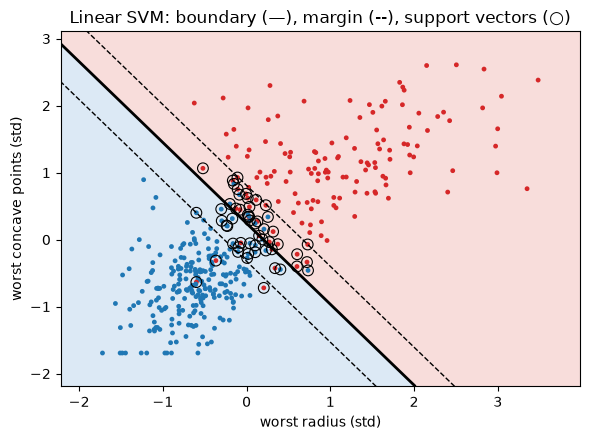

In [3]:
def plot_svm_2d(model, X, y, ax, title, show_sv=True, feature_names=two_features):
    """Draw the decision function: boundary (0) and margin edges (±1), plus circled support vectors."""
    pad = 0.5
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 250),
                         np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-1e9, 0, 1e9], colors=["#f4c7c3", "#c6dbef"], alpha=0.6)
    ax.contour(xx, yy, zz, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"], linewidths=[1, 2, 1])
    ax.scatter(X[:, 0], X[:, 1], c=np.where(y == 0, "#d62728", "#1f77b4"), s=12, edgecolors="none")
    if show_sv and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=60, facecolors="none", edgecolors="k", linewidths=0.8)
    ax.set(title=title, xlabel=feature_names[0] + " (std)", ylabel=feature_names[1] + " (std)")


fig, ax = plt.subplots(figsize=(6, 4.5))
plot_svm_2d(linear_svm, X2_tr, y2_tr, ax, "Linear SVM: boundary (—), margin (--), support vectors (○)")
plt.tight_layout()
plt.show()

**The key property:** only support vectors matter. Let's prove it — refit using **only** the support vectors and compare the boundary.

In [4]:
sv_idx = linear_svm.support_
refit = SVC(kernel="linear", C=1.0).fit(X2_tr[sv_idx], y2_tr[sv_idx])
print("w from all rows      :", w.round(4), "| b:", round(b, 4))
print("w from support vecs  :", refit.coef_.ravel().round(4), "| b:", round(refit.intercept_[0], 4))
same_preds = np.mean(refit.predict(X2_va) == linear_svm.predict(X2_va))
print(f"validation predictions identical on {same_preds:.1%} of rows")

w from all rows      : [-2.1328 -1.7662] | b: 0.4283
w from support vecs  : [-2.1328 -1.7662] | b: 0.4283
validation predictions identical on 100.0% of rows


### ✍️ Your Turn

Using `linear_svm`, compute `n_sv_fraction`: the **fraction** of training tumours that are support vectors (a number between 0 and 1).

In [5]:
n_sv_fraction = None  # TODO: your code here
check("n_sv_fraction", n_sv_fraction, len(linear_svm.support_) / len(y2_tr),
      hint="linear_svm.support_ holds the indices of the support vectors; divide by the number of training rows.")

⏳ n_sv_fraction: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_sv_fraction = len(linear_svm.support_) / len(y2_tr)      # or linear_svm.n_support_.sum() / len(y2_tr)
check("n_sv_fraction", n_sv_fraction, len(linear_svm.support_) / len(y2_tr))
```

A large fraction of support vectors means the classes overlap a lot (many rows sit inside the margin). It also means slower predictions, because the kernel version compares every new row with every support vector.
</details>

> 💡 **Interview angle:** "What are support vectors?" — the training points on or inside the margin (plus misclassified ones). They alone define the boundary: delete any other point and the model doesn't change. That's why an SVM is **memory-light at prediction time** but also why outliers *inside* the margin can pull the boundary.

## 2. Soft Margin and the C Knob 🟢

Real classes overlap, so a **hard margin** (no point allowed inside the street) usually doesn't exist. The **soft margin** adds a slack $\xi_i \ge 0$ per point — how far it intrudes — and pays $C$ per unit of slack:

$$\min_{w,b,\xi}\ \tfrac12\lVert w\rVert^2 + C\sum_i \xi_i \quad \text{s.t.}\quad y_i(w\cdot x_i+b)\ \ge\ 1-\xi_i$$

| `C` | Behaviour | Bias / variance |
|---|---|---|
| small (0.01) | slack is cheap → **wide** street, many support vectors | more bias, less variance (strong regularization) |
| large (100) | slack is expensive → **narrow** street, fits the training points hard | less bias, more variance |
| → ∞ | hard margin (only works if data are separable) | |

`C` works like logistic regression's `C`: it is the **inverse** of regularization strength.

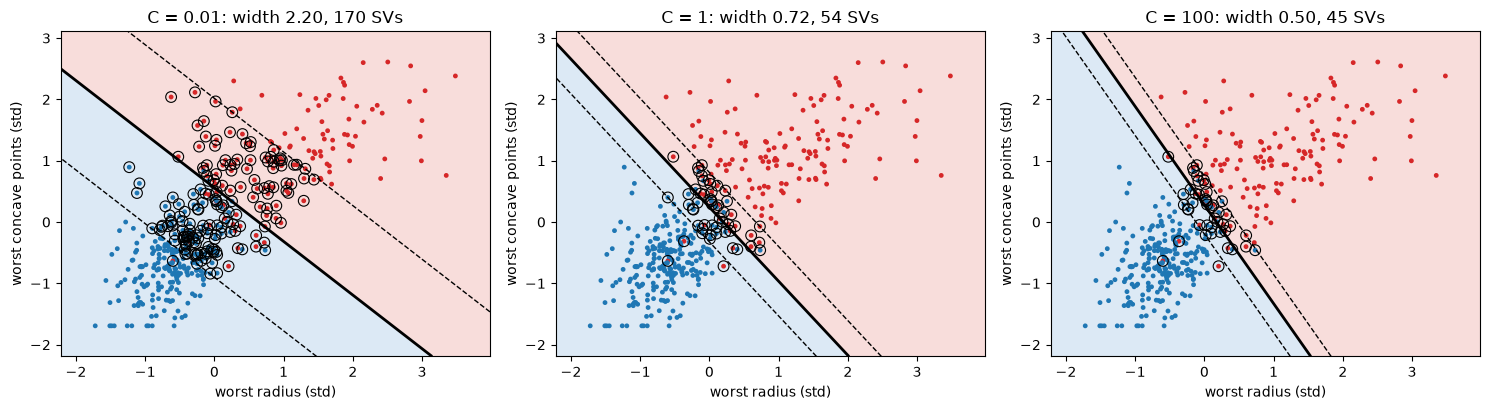

     C  margin width  support vectors  train acc  val acc
  0.01         2.196              170      0.947    0.930
  1.00         0.722               54      0.957    0.924
100.00         0.501               45      0.957    0.924

As C grows the margin shrinks ✅ and the number of support vectors drops.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
c_rows = []
for ax, C in zip(axes, [0.01, 1, 100]):
    model = SVC(kernel="linear", C=C).fit(X2_tr, y2_tr)
    width = 2 / np.linalg.norm(model.coef_)
    c_rows.append({"C": C, "margin width": round(width, 3), "support vectors": int(model.n_support_.sum()),
                   "train acc": round(model.score(X2_tr, y2_tr), 3), "val acc": round(model.score(X2_va, y2_va), 3)})
    plot_svm_2d(model, X2_tr, y2_tr, ax, f"C = {C}: width {width:.2f}, {model.n_support_.sum()} SVs")
plt.tight_layout()
plt.show()
c_table = pd.DataFrame(c_rows)
print(c_table.to_string(index=False))
widths = c_table["margin width"].to_numpy()
print("\nAs C grows the margin", "shrinks ✅" if np.all(np.diff(widths) <= 1e-9) else "does not shrink monotonically",
      "and the number of support vectors", "drops." if c_table["support vectors"].is_monotonic_decreasing else "changes non-monotonically.")

### ✍️ Your Turn

Fit `SVC(kernel="linear", C=10)` on `X2_tr, y2_tr` and store its **margin width** $2/\lVert w\rVert$ in `width_c10`.

In [7]:
width_c10 = None  # TODO: your code here
check("width_c10", width_c10, 2 / np.linalg.norm(SVC(kernel="linear", C=10).fit(X2_tr, y2_tr).coef_),
      hint="model.coef_ is w; use np.linalg.norm.")

⏳ width_c10: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
model_c10 = SVC(kernel="linear", C=10).fit(X2_tr, y2_tr)
width_c10 = 2 / np.linalg.norm(model_c10.coef_)
check("width_c10", width_c10, 2 / np.linalg.norm(SVC(kernel="linear", C=10).fit(X2_tr, y2_tr).coef_))
```
</details>

> 💡 **Interview angle:** "What does `C` do?" — it trades margin width against training errors. Small `C` = strong regularization (wide margin, may underfit); large `C` = weak regularization (narrow margin, may overfit). Tune it on a **log scale** with cross-validation.

## 3. The Math: Hinge Loss, Primal, and Dual 🟡

### Hinge loss vs log loss
At the optimum the slack is $\xi_i = \max(0,\ 1 - y_i f(x_i))$ with $y_i\in\{-1,+1\}$, so the soft-margin SVM is exactly **L2-regularized hinge loss**:

$$\min_{w,b}\ \frac{\lambda}{2}\lVert w\rVert^2 + \frac1n\sum_i \underbrace{\max\big(0,\ 1 - y_i(w\cdot x_i+b)\big)}_{\text{hinge}}, \qquad \lambda = \frac{1}{C\,n}$$

Call $m = y\,f(x)$ the **functional margin** (positive = correct side). Compare the losses as functions of $m$:

| Loss | Formula in $m$ | Behaviour |
|---|---|---|
| 0–1 | $[m \le 0]$ | what we really care about; not differentiable, NP-hard to optimize |
| **Hinge** (SVM) | $\max(0, 1-m)$ | **exactly zero** once a point is safely beyond the margin → sparse solution (support vectors); no probabilities |
| **Log loss** (logistic regression) | $\log_2(1+e^{-m})$ | never zero → every point keeps pulling; gives probabilities |

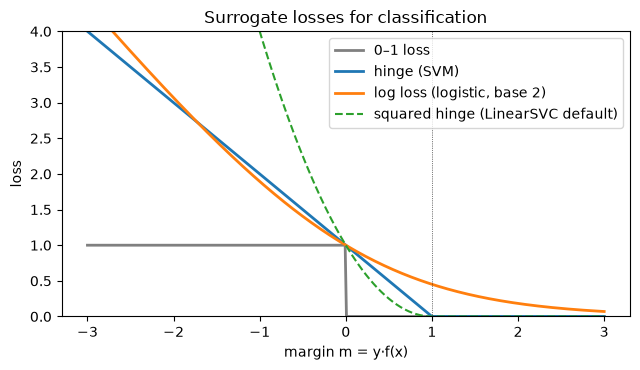

m = -1.0 | hinge 2.000 | log loss 1.895
m =  0.0 | hinge 1.000 | log loss 1.000
m =  0.5 | hinge 0.500 | log loss 0.684
m =  1.0 | hinge 0.000 | log loss 0.452
m =  2.0 | hinge 0.000 | log loss 0.183


In [8]:
m = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(m, (m <= 0).astype(float), label="0–1 loss", color="gray", lw=2)
ax.plot(m, np.maximum(0, 1 - m), label="hinge (SVM)", lw=2)
ax.plot(m, np.log2(1 + np.exp(-m)), label="log loss (logistic, base 2)", lw=2)
ax.plot(m, np.maximum(0, 1 - m) ** 2, label="squared hinge (LinearSVC default)", lw=1.5, ls="--")
ax.set(xlabel="margin m = y·f(x)", ylabel="loss", ylim=(0, 4), title="Surrogate losses for classification")
ax.axvline(1, color="k", lw=0.5, ls=":")
ax.legend()
plt.tight_layout()
plt.show()

for mm in [-1.0, 0.0, 0.5, 1.0, 2.0]:
    print(f"m = {mm:4.1f} | hinge {max(0, 1 - mm):.3f} | log loss {np.log2(1 + np.exp(-mm)):.3f}")

### Primal vs dual, in plain words

- **Primal** = the problem above: search over the weights $w$ (one per feature). Natural when you have **many rows and few features** — `LinearSVC` and SGD solve (a version of) the primal.
- **Dual** = an equivalent problem with **one weight $\alpha_i$ per training row** (Lagrange multipliers for the margin constraints):

$$\max_{\alpha}\ \sum_i \alpha_i - \tfrac12\sum_{i,j}\alpha_i\alpha_j y_i y_j\,\underbrace{x_i\cdot x_j}_{\text{only dot products}} \quad\text{s.t.}\quad 0\le\alpha_i\le C,\ \ \sum_i\alpha_i y_i = 0$$

The solution gives $w=\sum_i \alpha_i y_i x_i$ and $f(x) = \sum_i \alpha_i y_i\,(x_i\cdot x) + b$. Three facts interviewers want:
1. $\alpha_i = 0$ for points safely outside the margin → **only support vectors have $\alpha_i > 0$**.
2. $0 < \alpha_i < C$: the point sits exactly **on** the margin ($y_i f(x_i) = 1$); $\alpha_i = C$: it is **inside** the margin or misclassified.
3. Data appear **only through dot products $x_i\cdot x_j$** → replace them with a kernel $K(x_i, x_j)$ and you get a non-linear SVM for free (section 4). This is why kernel `SVC` (LIBSVM) solves the dual.

Scikit-learn stores $\alpha_i y_i$ in `dual_coef_`. Let's verify every fact on our fitted model.

In [9]:
alpha_y = linear_svm.dual_coef_.ravel()               # α_i · y_i for each support vector (y in {-1, +1})
w_from_dual = alpha_y @ linear_svm.support_vectors_
assert np.allclose(w_from_dual, linear_svm.coef_.ravel())
print("✅ w = Σ α_i y_i x_i matches coef_:", w_from_dual.round(4))

alpha = np.abs(alpha_y)
C_used = linear_svm.C
at_bound = np.isclose(alpha, C_used, atol=1e-8)
f_sv = linear_svm.decision_function(linear_svm.support_vectors_)
y_pm = np.where(y2_tr[linear_svm.support_] == 1, 1, -1)   # sklearn's +1 class is classes_[1]
print(f"all 0 < α ≤ C: {bool(np.all((alpha > 0) & (alpha <= C_used + 1e-9)))}")
print(f"free SVs (0 < α < C): {(~at_bound).sum()} → their y·f(x) ≈ {np.round(y_pm[~at_bound] * f_sv[~at_bound], 3)}")
print(f"bounded SVs (α = C): {at_bound.sum()} → max y·f(x) among them = {(y_pm[at_bound] * f_sv[at_bound]).max():.3f} (≤ 1: inside the margin or wrong side)")

✅ w = Σ α_i y_i x_i matches coef_: [-2.1328 -1.7662]
all 0 < α ≤ C: True
free SVs (0 < α < C): 2 → their y·f(x) ≈ [1. 1.]
bounded SVs (α = C): 52 → max y·f(x) among them = 0.978 (≤ 1: inside the margin or wrong side)


> 💡 **Interview angle:** "Why solve the dual?" — (1) the data enter only via dot products, so kernels plug in; (2) the solution is sparse in $\alpha$ (support vectors); (3) its size depends on $n$, not on the (possibly infinite) feature dimension. The price: a kernel matrix of size $n \times n$ — which is why kernel SVMs don't scale to millions of rows.

## 4. The Kernel Trick: Polynomial and RBF 🟡

Some boundaries are curved. One fix: map every point into a bigger feature space $\phi(x)$ (squares, products, …) where a straight boundary works. The problem: $\phi(x)$ can be enormous — or infinite.

**The kernel trick:** the dual only needs dot products $\phi(x_i)\cdot\phi(x_j)$. A **kernel** $K(x_i, x_j)$ computes that dot product *directly from the original features*, without ever building $\phi$.

| Kernel | $K(x, z)$ | Hidden feature space | scikit-learn |
|---|---|---|---|
| Linear | $x\cdot z$ | the original features | `kernel="linear"` |
| Polynomial | $(\gamma\, x\cdot z + r)^d$ | all monomials up to degree $d$ | `kernel="poly", degree=d, gamma=γ, coef0=r` |
| RBF (Gaussian) | $\exp(-\gamma\lVert x-z\rVert^2)$ | **infinite**-dimensional | `kernel="rbf", gamma=γ` |

**Proof on real numbers.** For 2 features, degree 2, $\gamma=1$, $r=1$: $(x\cdot z+1)^2 = \phi(x)\cdot\phi(z)$ with $\phi(x) = [1,\ \sqrt2 x_1,\ \sqrt2 x_2,\ x_1^2,\ \sqrt2 x_1x_2,\ x_2^2]$.

In [10]:
def phi_poly2(X):
    """Explicit feature map whose dot product equals the degree-2 polynomial kernel (gamma=1, coef0=1)."""
    x1, x2 = X[:, 0], X[:, 1]
    s = np.sqrt(2)
    return np.column_stack([np.ones(len(X)), s * x1, s * x2, x1 ** 2, s * x1 * x2, x2 ** 2])


A, B = X2_tr[:5], X2_va[:4]
explicit = phi_poly2(A) @ phi_poly2(B).T                    # build φ, then dot products (6-D here)
via_kernel = polynomial_kernel(A, B, degree=2, gamma=1, coef0=1)   # never builds φ
assert np.allclose(explicit, via_kernel)
print("✅ φ(x)·φ(z) == (x·z + 1)² for every pair:\n", via_kernel.round(3))

d_orig = 30
print(f"\nWith {d_orig} features, a degree-3 map would need {PolynomialFeatures(3).fit(np.zeros((1, d_orig))).n_output_features_:,} columns; "
      "the kernel still costs one dot product.")

✅ φ(x)·φ(z) == (x·z + 1)² for every pair:
 [[3.181 0.913 1.771 0.827]
 [2.051 7.182 5.488 2.236]
 [0.746 6.338 5.677 1.76 ]
 [0.163 2.494 2.516 0.008]
 [0.337 2.75  3.233 0.009]]

With 30 features, a degree-3 map would need 5,456 columns; the kernel still costs one dot product.


The **RBF kernel** is a *similarity*: 1 when two points coincide, falling towards 0 as they move apart. `gamma` sets how fast it falls — the "reach" of each support vector is about $1/\sqrt{\gamma}$.

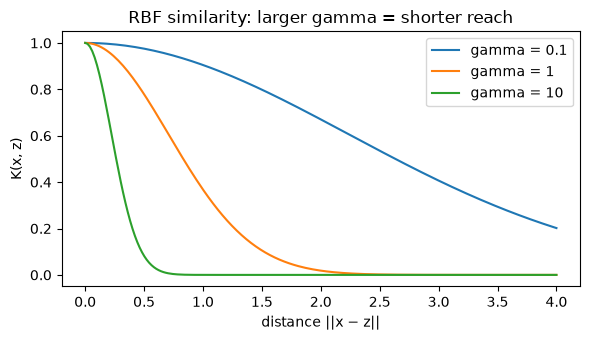

In [11]:
dist = np.linspace(0, 4, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
for g in [0.1, 1, 10]:
    ax.plot(dist, np.exp(-g * dist ** 2), label=f"gamma = {g}")
ax.set(xlabel="distance ||x − z||", ylabel="K(x, z)", title="RBF similarity: larger gamma = shorter reach")
ax.legend()
plt.tight_layout()
plt.show()

Now a real non-linear problem: **three wine cultivars** from two chemical measurements (`flavanoids`, `color_intensity`). We compare the three kernels with 5-fold cross-validation and draw their decision regions.

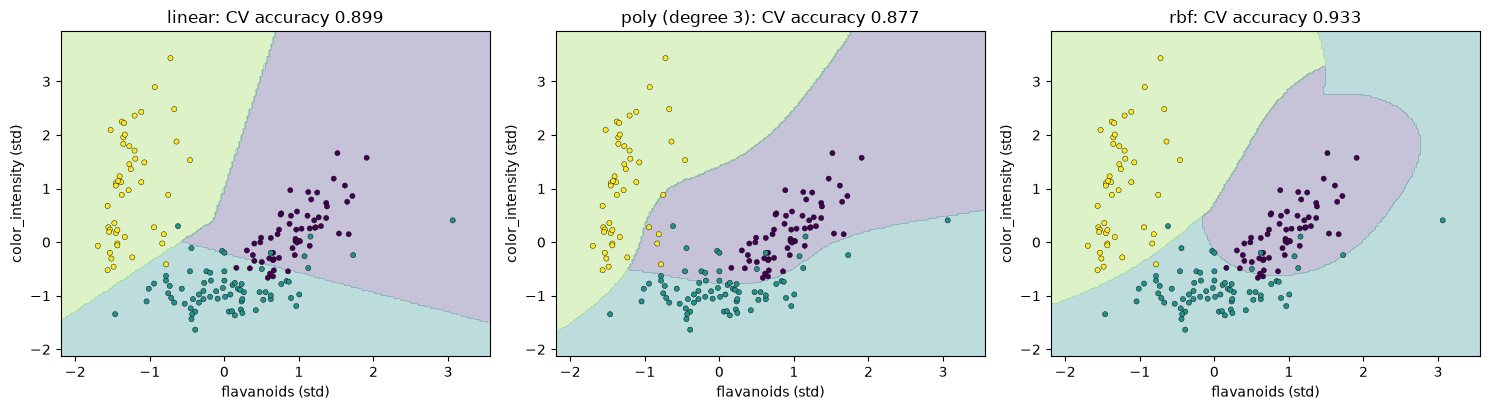

{'linear': 0.899, 'poly (degree 3)': 0.877, 'rbf': 0.933} → best kernel on this pair: rbf


In [12]:
wine = load_wine()
wine_pair = ["flavanoids", "color_intensity"]
Xw2_raw = wine.data[:, [wine.feature_names.index(f) for f in wine_pair]]
yw = wine.target
Xw2 = StandardScaler().fit_transform(Xw2_raw)     # for pictures only; CV below scales inside a Pipeline
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def plot_regions(model, X, y, ax, title, names=wine_pair):
    """Colour the plane by predicted class (works for any number of classes)."""
    pad = 0.5
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 200),
                         np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 200))
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="viridis", levels=np.arange(-0.5, len(np.unique(y)) + 0.5))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=14, edgecolors="k", linewidths=0.3)
    ax.set(title=title, xlabel=names[0] + " (std)", ylabel=names[1] + " (std)")


kernels = {"linear": SVC(kernel="linear"), "poly (degree 3)": SVC(kernel="poly", degree=3), "rbf": SVC(kernel="rbf")}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
kernel_scores = {}
for ax, (name, est) in zip(axes, kernels.items()):
    kernel_scores[name] = cross_val_score(make_pipeline(StandardScaler(), est), Xw2_raw, yw, cv=cv5).mean()
    plot_regions(est.fit(Xw2, yw), Xw2, yw, ax, f"{name}: CV accuracy {kernel_scores[name]:.3f}")
plt.tight_layout()
plt.show()
best_kernel = max(kernel_scores, key=kernel_scores.get)
print({k: round(float(v), 3) for k, v in kernel_scores.items()}, "→ best kernel on this pair:", best_kernel)

### ✍️ Your Turn

Compute the polynomial kernel $K(x,z) = (\gamma\,x\cdot z + r)^d$ **by hand with NumPy** for `x = [1, 2]`, `z = [3, -1]`, `gamma = 0.5`, `coef0 = 1`, `degree = 3`. Store the number in `k_poly`.

In [13]:
x_vec, z_vec = np.array([1.0, 2.0]), np.array([3.0, -1.0])
k_poly = None  # TODO: your code here
check("k_poly", k_poly, polynomial_kernel([x_vec], [z_vec], degree=3, gamma=0.5, coef0=1)[0, 0],
      hint="x·z = 1·3 + 2·(−1). Then (0.5·x·z + 1) ** 3.")

⏳ k_poly: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_vec, z_vec = np.array([1.0, 2.0]), np.array([3.0, -1.0])
k_poly = (0.5 * (x_vec @ z_vec) + 1) ** 3          # (0.5·1 + 1)³ = 3.375
check("k_poly", k_poly, polynomial_kernel([x_vec], [z_vec], degree=3, gamma=0.5, coef0=1)[0, 0])
```
</details>

> 💡 **Interview angle:** "Explain the kernel trick." — The SVM dual touches data only through dot products. A kernel $K(x,z)=\phi(x)\cdot\phi(z)$ computes the dot product in a high- (even infinite-) dimensional space directly from the original features, so we get a linear separator *there* — a non-linear one *here* — without ever building $\phi$. A valid kernel must be symmetric positive semi-definite (Mercer's condition).

## 5. Tuning C and gamma 🟡

For the RBF kernel the two knobs interact:

| | small `gamma` (long reach) | large `gamma` (short reach) |
|---|---|---|
| **small `C`** | nearly linear, smooth → underfit | many small bumps but heavily regularized |
| **large `C`** | smooth but fits hard | **islands around single points** → overfit |

The picture below is a C × gamma grid on the wine pair. Read it like a bias–variance map.

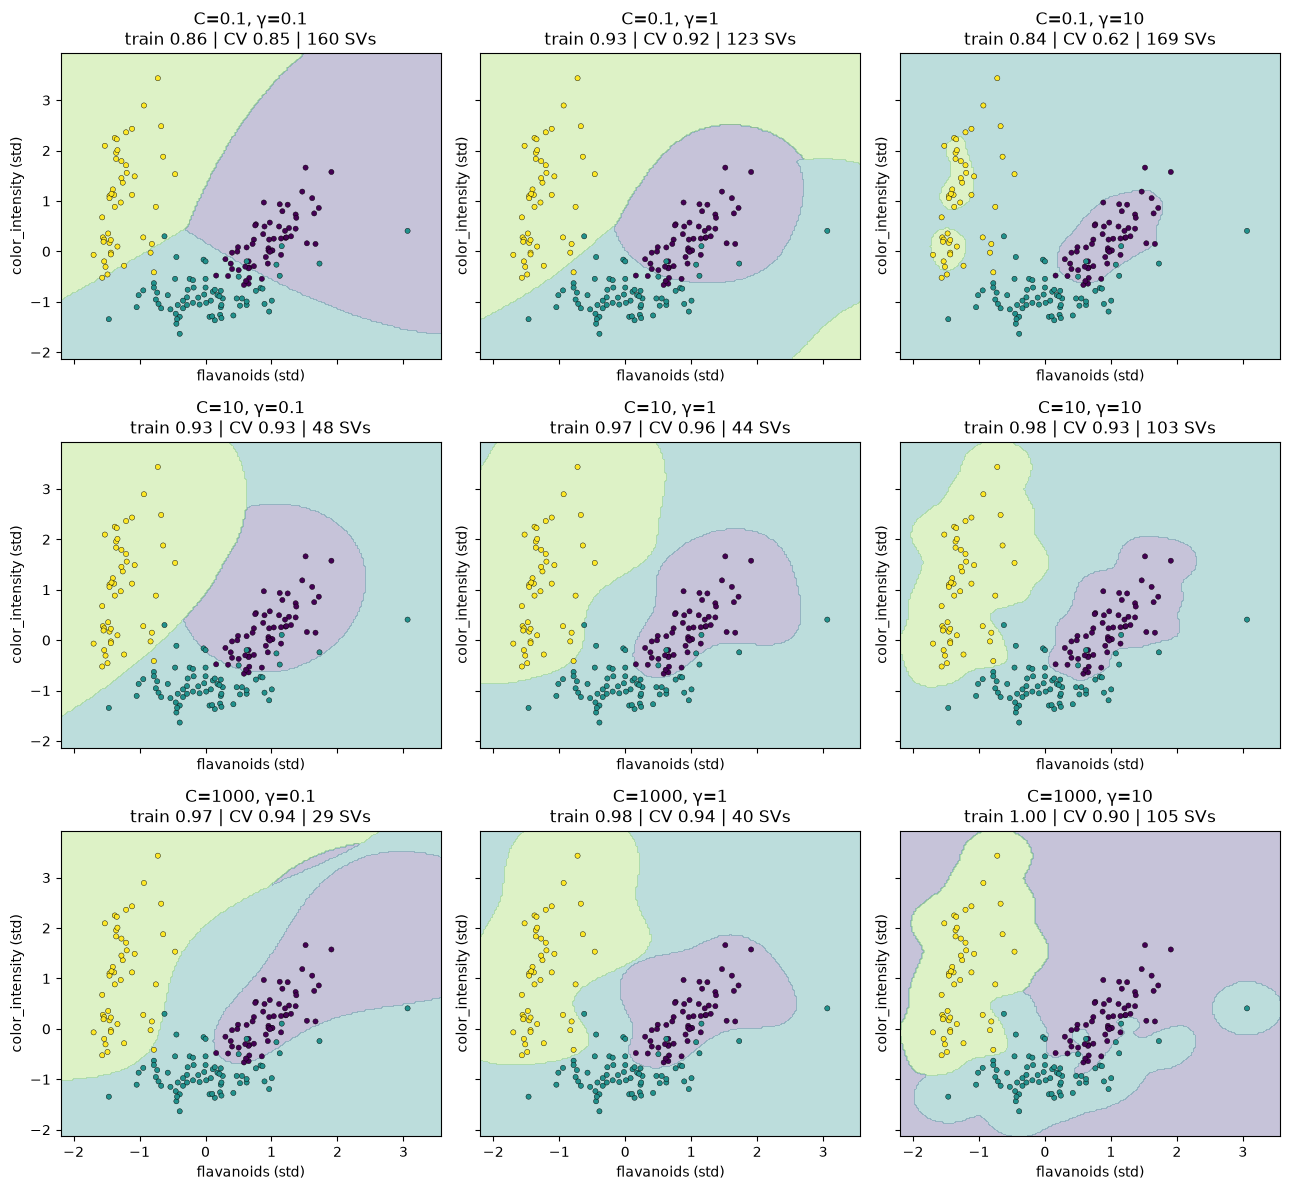

     C  gamma  train acc  CV acc  SVs
   0.1    0.1      0.860   0.854  160
   0.1    1.0      0.927   0.921  123
   0.1   10.0      0.843   0.619  169
  10.0    0.1      0.927   0.927   48
  10.0    1.0      0.966   0.955   44
  10.0   10.0      0.983   0.933  103
1000.0    0.1      0.966   0.944   29
1000.0    1.0      0.978   0.939   40
1000.0   10.0      1.000   0.904  105

best CV cell        : C=10, gamma=1 → CV 0.955
highest train acc   : C=1000, gamma=10 → train 1.000 but CV 0.904 (overfits)


In [14]:
C_grid, gamma_grid = [0.1, 10, 1000], [0.1, 1, 10]
fig, axes = plt.subplots(3, 3, figsize=(13, 12), sharex=True, sharey=True)
grid_rows = []
for i, C in enumerate(C_grid):
    for j, g in enumerate(gamma_grid):
        est = SVC(C=C, gamma=g)
        cv_acc = cross_val_score(make_pipeline(StandardScaler(), SVC(C=C, gamma=g)), Xw2_raw, yw, cv=cv5).mean()
        est.fit(Xw2, yw)
        grid_rows.append({"C": C, "gamma": g, "train acc": est.score(Xw2, yw), "CV acc": cv_acc, "SVs": int(est.n_support_.sum())})
        plot_regions(est, Xw2, yw, axes[i, j], f"C={C}, γ={g}\ntrain {est.score(Xw2, yw):.2f} | CV {cv_acc:.2f} | {est.n_support_.sum()} SVs")
plt.tight_layout()
plt.show()
grid_df = pd.DataFrame(grid_rows).round(3)
print(grid_df.to_string(index=False))
best_cell = grid_df.loc[grid_df["CV acc"].idxmax()]
memorizer = grid_df.loc[grid_df["train acc"].idxmax()]
print(f"\nbest CV cell        : C={best_cell['C']:g}, gamma={best_cell['gamma']:g} → CV {best_cell['CV acc']:.3f}")
print(f"highest train acc   : C={memorizer['C']:g}, gamma={memorizer['gamma']:g} → train {memorizer['train acc']:.3f} but CV {memorizer['CV acc']:.3f} "
      f"({'overfits' if memorizer['CV acc'] < best_cell['CV acc'] else 'also best'})")

**Sensible defaults.** `gamma="scale"` sets $\gamma = 1 / (n_\text{features}\cdot \operatorname{Var}(X))$ — after standardization that is simply $1/n_\text{features}$. Start with `C=1, gamma="scale"`, then search both **on a log grid**. Here is the full 30-feature breast-cancer problem as a CV heatmap:

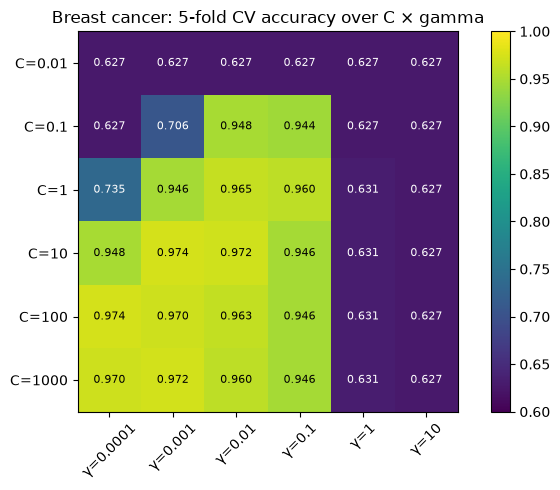

best: C=10, gamma=0.001, CV accuracy 0.9742
✅ best value is inside the grid, not on an edge
gamma='scale' after standardization would be 1/30 = 0.0333


In [15]:
X_bc, y_bc = cancer.data, cancer.target
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(X_bc, y_bc, test_size=0.25, stratify=y_bc, random_state=SEED)

svm_pipe = make_pipeline(StandardScaler(), SVC())
param_grid = {"svc__C": np.logspace(-2, 3, 6), "svc__gamma": np.logspace(-4, 1, 6)}
search = GridSearchCV(svm_pipe, param_grid, cv=cv5, n_jobs=1).fit(X_bc_tr, y_bc_tr)
heat = pd.DataFrame(search.cv_results_["mean_test_score"].reshape(6, 6),
                    index=[f"C={c:g}" for c in param_grid["svc__C"]], columns=[f"γ={g:g}" for g in param_grid["svc__gamma"]])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heat.to_numpy(), cmap="viridis", vmin=0.6, vmax=1.0)
ax.set_xticks(range(6), heat.columns, rotation=45)
ax.set_yticks(range(6), heat.index)
for (r, c), v in np.ndenumerate(heat.to_numpy()):
    ax.text(c, r, f"{v:.3f}", ha="center", va="center", color="w" if v < 0.85 else "k", fontsize=8)
ax.set_title("Breast cancer: 5-fold CV accuracy over C × gamma")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

best_C, best_g = search.best_params_["svc__C"], search.best_params_["svc__gamma"]
on_edge = best_C in (param_grid["svc__C"][0], param_grid["svc__C"][-1]) or best_g in (param_grid["svc__gamma"][0], param_grid["svc__gamma"][-1])
print(f"best: C={best_C:g}, gamma={best_g:g}, CV accuracy {search.best_score_:.4f}")
print("⚠️ best value is on the grid edge — widen the grid" if on_edge else "✅ best value is inside the grid, not on an edge")
print(f"gamma='scale' after standardization would be 1/30 = {1 / 30:.4f}")

### ✍️ Your Turn

Compute `gamma_scale_raw`: the value `gamma="scale"` would use on the **raw, unscaled** 13-feature wine data `wine.data`. Compare it with the standardized value `1/13 ≈ 0.077` and think about what that means for the kernel's reach.

In [16]:
gamma_scale_raw = None  # TODO: your code here
check("gamma_scale_raw", gamma_scale_raw, SVC().fit(wine.data, wine.target)._gamma,
      hint="1 / (n_features * X.var()) — X.var() is the variance of ALL values in the matrix.")

⏳ gamma_scale_raw: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
gamma_scale_raw = 1 / (wine.data.shape[1] * wine.data.var())
check("gamma_scale_raw", gamma_scale_raw, SVC().fit(wine.data, wine.target)._gamma)
```

It is tiny (≈ 1e-5) because `proline` values are in the hundreds to thousands, so `X.var()` is huge. The "one gamma for all features" is dominated by the largest-scale feature — the next section shows the damage.
</details>

> 💡 **Interview angle:** "Your RBF SVM gets 100% train accuracy and poor validation accuracy — which knob?" — `gamma` too large (each support vector only influences its immediate neighbourhood, so the model memorizes) and/or `C` too large. Lower them, and search both on log scales with CV.

## 6. Scaling Is Mandatory 🟢

The margin $2/\lVert w\rVert$ and the RBF distance $\lVert x - z\rVert^2$ are measured in **raw feature units**. If one feature is in the thousands and another is below 1, the big one owns the geometry and the others are ignored. Wine is a perfect real example:

In [17]:
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
stds = wine_df.std().sort_values(ascending=False)
print("feature standard deviations (largest 3 / smallest 2):")
print(pd.concat([stds.head(3), stds.tail(2)]).round(3).to_string())

diffs = wine.data[:, None, :] - wine.data[None, :, :]           # all pairwise differences (178 × 178 × 13)
share = (diffs[..., wine.feature_names.index("proline")] ** 2).sum() / (diffs ** 2).sum()
print(f"\nshare of total squared distance coming from 'proline' alone: {share:.1%}")
del diffs

unscaled = cross_val_score(SVC(), wine.data, wine.target, cv=cv5).mean()
scaled = cross_val_score(make_pipeline(StandardScaler(), SVC()), wine.data, wine.target, cv=cv5).mean()
print(f"RBF SVM, 5-fold CV accuracy — unscaled: {unscaled:.3f} | StandardScaler in a Pipeline: {scaled:.3f}")

feature standard deviations (largest 3 / smallest 2):
proline                 314.907
magnesium                14.282
alcalinity_of_ash         3.340
hue                       0.229
nonflavanoid_phenols      0.124

share of total squared distance coming from 'proline' alone: 99.8%
RBF SVM, 5-fold CV accuracy — unscaled: 0.674 | StandardScaler in a Pipeline: 0.983


**Assumption behind the kernel: Euclidean distance is meaningful.** Scaling fixes units, but not *irrelevant* features: every column counts equally in $\lVert x-z\rVert$. Experiment — add pure-noise columns (a controlled synthetic addition to real data) and watch the RBF SVM degrade:

In [18]:
noise_rows = []
for n_noise in [0, 10, 50, 200]:
    noise = np.random.default_rng(0).normal(size=(len(wine.data), n_noise))
    X_noisy = np.hstack([wine.data, noise])
    acc = cross_val_score(make_pipeline(StandardScaler(), SVC()), X_noisy, wine.target, cv=cv5).mean()
    noise_rows.append({"noise features added": n_noise, "RBF SVM CV acc": round(acc, 3)})
print(pd.DataFrame(noise_rows).to_string(index=False))
print("→ irrelevant features dilute distances; do feature selection or use a model that picks features (trees, L1).")

 noise features added  RBF SVM CV acc
                    0           0.983
                   10           0.983
                   50           0.955
                  200           0.887
→ irrelevant features dilute distances; do feature selection or use a model that picks features (trees, L1).


### ✍️ Your Turn

Store in `largest_std_feature` the **name** (a string) of the wine feature with the largest standard deviation. Use `wine_df`.

In [19]:
largest_std_feature = None  # TODO: your code here
check("largest_std_feature", largest_std_feature, wine_df.std().idxmax(), hint="DataFrame.std() then .idxmax().")

⏳ largest_std_feature: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
largest_std_feature = wine_df.std().idxmax()        # 'proline'
check("largest_std_feature", largest_std_feature, wine_df.std().idxmax())
```
</details>

> 💡 **Interview angle:** "Which models need feature scaling?" — anything built on distances, dot products, or penalties: SVMs, KNN, k-means, PCA, regularized linear models, neural nets. Trees and tree ensembles don't. Always fit the scaler **inside** a `Pipeline` so CV folds don't leak.

## 7. Multiclass: One-vs-One vs One-vs-Rest 🟡

An SVM is a binary classifier. For $k$ classes there are two strategies:

| Strategy | Models trained | Each model sees | Used by |
|---|---|---|---|
| **One-vs-One (OvO)** | $k(k-1)/2$ | only the rows of its **2** classes | `SVC` / `NuSVC` (LIBSVM) — prediction by voting |
| **One-vs-Rest (OvR)** | $k$ | **all** rows (one class vs everything else) | `LinearSVC`, `OneVsRestClassifier(SVC())` |

OvO trains many *small* problems. Because kernel SVM cost grows faster than linearly in $n$, many small problems are usually cheaper than a few big ones. `SVC(decision_function_shape="ovr")` (the default) only *reshapes* the OvO votes into one score per class — the training is still OvO.

In [20]:
X_dig, y_dig = load_digits(return_X_y=True)          # 1,797 real 8×8 handwritten digits, 10 classes
multi_rows = []
for name, est in [("SVC (OvO inside)", SVC()), ("OneVsRestClassifier(SVC)", OneVsRestClassifier(SVC())),
                  ("LinearSVC (OvR)", LinearSVC())]:
    res = cross_validate(make_pipeline(StandardScaler(), est), X_dig, y_dig, cv=cv5)
    multi_rows.append({"model": name, "CV acc": res["test_score"].mean(), "fit s/fold": res["fit_time"].mean(),
                       "predict s/fold": res["score_time"].mean()})
print(pd.DataFrame(multi_rows).round(4).to_string(index=False))

ovo_model = make_pipeline(StandardScaler(), SVC(decision_function_shape="ovo")).fit(X_dig, y_dig)
ovr_shape = make_pipeline(StandardScaler(), SVC()).fit(X_dig, y_dig).decision_function(X_dig[:3]).shape
print(f"\nOvO decision_function shape: {ovo_model.decision_function(X_dig[:3]).shape} (= 10·9/2 pairwise models)")
print(f"default 'ovr' shape         : {ovr_shape} (votes aggregated per class)")

                   model  CV acc  fit s/fold  predict s/fold
        SVC (OvO inside)  0.9839      0.0172          0.0094
OneVsRestClassifier(SVC)  0.9822      0.0618          0.0273
         LinearSVC (OvR)  0.9560      0.2322          0.0005

OvO decision_function shape: (3, 45) (= 10·9/2 pairwise models)
default 'ovr' shape         : (3, 10) (votes aggregated per class)


> 💡 **Interview angle:** "How does an SVM do multiclass?" — `SVC` trains $k(k-1)/2$ one-vs-one models and votes; `LinearSVC` trains $k$ one-vs-rest models. OvO is cheaper for kernel SVMs (small subproblems), OvR is natural for linear models. Crammer–Singer is a single joint multiclass objective (`LinearSVC(multi_class="crammer_singer")`).

## 8. Probabilities: Platt Scaling and CalibratedClassifierCV 🔴

An SVM outputs a **score** $f(x)$ (signed distance to the boundary), not a probability. **Platt scaling** fits a one-feature logistic regression on held-out scores: $P(y=1\mid x) = 1/(1+e^{A f(x)+B})$.

**What changed in scikit-learn 1.9 (verified in the installed source):** `SVC(probability=True)` (LIBSVM's internal 5-fold Platt scaling) is **deprecated in 1.9 and will be removed in 1.11**, together with the `probA_`/`probB_` attributes. The warning tells you the replacement: `CalibratedClassifierCV(SVC(), ensemble=False)`.

In [21]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    SVC(probability=True).fit(StandardScaler().fit_transform(X_bc_tr), y_bc_tr)
for wmsg in caught:
    print(f"{wmsg.category.__name__}: {wmsg.message}")

The modern way, on the breast-cancer split from section 5. `ensemble=False` = get out-of-fold decision scores with 5-fold CV, fit **one** sigmoid on them, then refit the SVM on all training rows (exactly what `probability=True` did, but transparent). We compare against squashing the raw score with a plain sigmoid (not calibrated) and logistic regression.

In [22]:
def binary_proba_report(name, proba, y_true):
    return {"model": name, "log loss": log_loss(y_true, proba), "Brier": brier_score_loss(y_true, proba),
            "accuracy@0.5": accuracy_score(y_true, (proba >= 0.5).astype(int))}


svm_fitted = make_pipeline(StandardScaler(), SVC()).fit(X_bc_tr, y_bc_tr)
raw_sigmoid = 1 / (1 + np.exp(-svm_fitted.decision_function(X_bc_te)))         # NOT calibrated
platt = CalibratedClassifierCV(make_pipeline(StandardScaler(), SVC()), method="sigmoid", ensemble=False, cv=cv5).fit(X_bc_tr, y_bc_tr)
isotonic = CalibratedClassifierCV(make_pipeline(StandardScaler(), SVC()), method="isotonic", ensemble=False, cv=cv5).fit(X_bc_tr, y_bc_tr)
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_bc_tr, y_bc_tr)

prob_rows = [binary_proba_report("SVC + raw sigmoid(score)", raw_sigmoid, y_bc_te),
             binary_proba_report("SVC + Platt (CalibratedClassifierCV)", platt.predict_proba(X_bc_te)[:, 1], y_bc_te),
             binary_proba_report("SVC + isotonic", isotonic.predict_proba(X_bc_te)[:, 1], y_bc_te),
             binary_proba_report("LogisticRegression", logreg.predict_proba(X_bc_te)[:, 1], y_bc_te)]
prob_df = pd.DataFrame(prob_rows).round(4)
print(prob_df.to_string(index=False))
print("\nlowest log loss:", prob_df.loc[prob_df["log loss"].idxmin(), "model"])
print("(This small test set has only", len(y_bc_te), "rows — treat differences in the 3rd decimal as noise.)")

                               model  log loss  Brier  accuracy@0.5
            SVC + raw sigmoid(score)    0.2533 0.0593         0.979
SVC + Platt (CalibratedClassifierCV)    0.0755 0.0203         0.979
                      SVC + isotonic    0.0745 0.0203         0.979
                  LogisticRegression    0.0679 0.0181         0.986

lowest log loss: LogisticRegression
(This small test set has only 143 rows — treat differences in the 3rd decimal as noise.)


**Already have a fitted SVM and a separate calibration set?** `cv="prefit"` was removed; wrap the model in `FrozenEstimator` so `CalibratedClassifierCV` fits only the sigmoid:

In [23]:
X_fit, X_calib, y_fit, y_calib = train_test_split(X_bc_tr, y_bc_tr, test_size=0.3, stratify=y_bc_tr, random_state=SEED)
base_svm = make_pipeline(StandardScaler(), SVC()).fit(X_fit, y_fit)
calibrated_prefit = CalibratedClassifierCV(FrozenEstimator(base_svm), method="sigmoid").fit(X_calib, y_calib)
p_prefit = calibrated_prefit.predict_proba(X_bc_te)[:, 1]
disagree = np.mean(base_svm.predict(X_bc_te) != (p_prefit >= 0.5))
print(f"prefit + FrozenEstimator: test log loss {log_loss(y_bc_te, p_prefit):.4f}")
print(f"rows where SVC.predict() and 'calibrated proba ≥ 0.5' disagree: {disagree:.1%} — Platt's intercept B can move the 0.5 point")

prefit + FrozenEstimator: test log loss 0.0975
rows where SVC.predict() and 'calibrated proba ≥ 0.5' disagree: 0.7% — Platt's intercept B can move the 0.5 point


> 💡 **Interview angle:** "How do you get probabilities from an SVM?" — fit a calibrator on **held-out** decision scores: Platt/sigmoid (few rows, monotone S-shape) or isotonic (more flexible, needs more data). In scikit-learn ≥ 1.9 use `CalibratedClassifierCV(SVC(), ensemble=False)` — `probability=True` is deprecated. Mention that the calibrated argmax may disagree with `predict()`, so pick one consistently.

## 9. Support Vector Regression and the ε-Tube 🟡

**SVR** turns the idea inside out: instead of a street that *no* point should enter, fit a tube of half-width $\varepsilon$ that *as many points as possible* sit **inside**. Errors smaller than $\varepsilon$ cost nothing (**ε-insensitive loss**):

$$\min_{w,b}\ \tfrac12\lVert w\rVert^2 + C\sum_i \max\big(0,\ |y_i - f(x_i)| - \varepsilon\big)$$

Points strictly inside the tube have $\alpha_i = 0$; only points on or outside it become support vectors. So a **wider tube → fewer support vectors → a flatter, simpler model**.

Real data: median house value (in $100k) vs median income for 1,500 California districts.

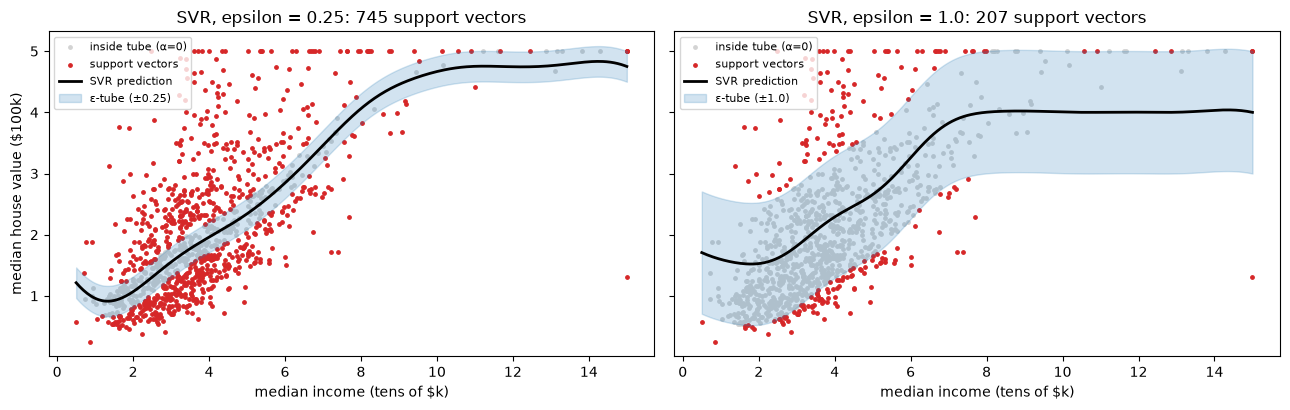

 epsilon  support vectors  SV fraction  test R²
    0.05              968        0.922    0.495
    0.25              745        0.710    0.492
    0.50              518        0.493    0.493
    1.00              207        0.197    0.426

wider tube → fewer support vectors: True


In [24]:
housing = fetch_california_housing(data_home=DATA_HOME)
idx_h = np.random.default_rng(0).choice(len(housing.target), 1500, replace=False)
x_inc = housing.data[idx_h][:, [housing.feature_names.index("MedInc")]]
y_val = housing.target[idx_h]
x_inc_tr, x_inc_te, y_val_tr, y_val_te = train_test_split(x_inc, y_val, test_size=0.3, random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
svr_rows = []
grid_x = np.linspace(x_inc.min(), x_inc.max(), 300).reshape(-1, 1)
for eps in [0.05, 0.25, 0.5, 1.0]:
    svr = make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=eps)).fit(x_inc_tr, y_val_tr)
    n_sv = len(svr[-1].support_)
    svr_rows.append({"epsilon": eps, "support vectors": n_sv, "SV fraction": n_sv / len(y_val_tr),
                     "test R²": svr.score(x_inc_te, y_val_te)})
    if eps in (0.25, 1.0):
        ax = axes[0 if eps == 0.25 else 1]
        curve = svr.predict(grid_x)
        sv_mask = np.zeros(len(y_val_tr), bool)
        sv_mask[svr[-1].support_] = True
        ax.scatter(x_inc_tr[~sv_mask, 0], y_val_tr[~sv_mask], s=6, color="lightgray", label="inside tube (α=0)")
        ax.scatter(x_inc_tr[sv_mask, 0], y_val_tr[sv_mask], s=6, color="#d62728", label="support vectors")
        ax.plot(grid_x[:, 0], curve, "k", lw=2, label="SVR prediction")
        ax.fill_between(grid_x[:, 0], curve - eps, curve + eps, color="#1f77b4", alpha=0.2, label=f"ε-tube (±{eps})")
        ax.set(title=f"SVR, epsilon = {eps}: {n_sv} support vectors", xlabel="median income (tens of $k)")
        ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("median house value ($100k)")
plt.tight_layout()
plt.show()
svr_df = pd.DataFrame(svr_rows).round(3)
print(svr_df.to_string(index=False))
print("\nwider tube → fewer support vectors:", bool(svr_df["support vectors"].is_monotonic_decreasing))

**Practical notes:** `epsilon` is in **target units**, so scale or reason about your target first (here 0.25 = $25k). `C` and `gamma` behave as in classification. SVR, like SVC, is $O(n^2)$+ — for big regression problems use `LinearSVR`, `SGDRegressor(loss="epsilon_insensitive")`, or gradient boosting.

### ✍️ Your Turn

Compute the **ε-insensitive loss** $\max(0, |r| - \varepsilon)$ for residuals `r = [-0.3, 0.05, 0.8]` with `eps = 0.1`, vectorized. Store the array in `eps_loss`.

In [25]:
r = np.array([-0.3, 0.05, 0.8])
eps = 0.1
eps_loss = None  # TODO: your code here
check("eps_loss", eps_loss, [0.2, 0.0, 0.7], hint="np.maximum(0, np.abs(r) - eps)")

⏳ eps_loss: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
r = np.array([-0.3, 0.05, 0.8])
eps = 0.1
eps_loss = np.maximum(0, np.abs(r) - eps)
check("eps_loss", eps_loss, [0.2, 0.0, 0.7])
```
The middle residual (0.05) is inside the tube, so it costs nothing and that point would not be a support vector.
</details>

> 💡 **Interview angle:** "How is SVR different from least-squares regression?" — SVR ignores errors smaller than ε (a dead zone) and penalizes larger errors **linearly**, so it is more robust to outliers than squared error and yields a sparse model (only points on/outside the tube matter). `epsilon` controls sparsity, `C` the flatness trade-off.

## 10. Big Data: LinearSVC, SGDClassifier, and Training Time 🔴

Kernel `SVC` must reason about pairs of rows, so its training time grows roughly between $n^2$ and $n^3$ (LIBSVM caches kernel rows; `cache_size` is in MB). Let's **measure** it instead of quoting it, on a real physics dataset: **MagicTelescope** (19,020 telescope images; gamma-ray signal `g` vs hadron background `h`; 10 numeric features).

| Tool | What it solves | Scales like |
|---|---|---|
| `SVC(kernel="rbf")` | exact kernel dual (LIBSVM, SMO) | ~$n^2$–$n^3$ |
| `LinearSVC` | linear primal/dual coordinate descent (LIBLINEAR); default **squared hinge** loss | ~$n \cdot d$ |
| `SGDClassifier(loss="hinge")` | linear SVM by stochastic gradient descent; supports `partial_fit` for streams | ~$n \cdot d$ per epoch |
| `Nystroem` + `LinearSVC` | approximate an RBF kernel with `n_components` features, then a linear SVM | ~$n \cdot m^2$ |

In [26]:
magic = fetch_openml("MagicTelescope", version=1, as_frame=True, data_home=DATA_HOME)
X_magic = magic.data.to_numpy(dtype=float)
y_magic = (magic.target == "g").to_numpy().astype(int)       # 1 = gamma-ray signal
print(f"MagicTelescope: {X_magic.shape[0]:,} rows × {X_magic.shape[1]} features | gamma share {y_magic.mean():.2f}")

X_mg_pool, X_mg_hold, y_mg_pool, y_mg_hold = train_test_split(X_magic, y_magic, test_size=3000, stratify=y_magic, random_state=SEED)

timing_rows = []
sizes = [1000, 2000, 4000, 8000, 16000]
for n in sizes:
    sub = np.random.default_rng(0).choice(len(y_mg_pool), n, replace=False)
    for name, est in [("SVC rbf", SVC()), ("LinearSVC", LinearSVC()), ("SGDClassifier hinge", SGDClassifier(loss="hinge", random_state=0))]:
        pipe = make_pipeline(StandardScaler(), est)
        start = time.perf_counter()
        pipe.fit(X_mg_pool[sub], y_mg_pool[sub])
        fit_s = time.perf_counter() - start
        start = time.perf_counter()
        acc = pipe.score(X_mg_hold, y_mg_hold)
        pred_ms = (time.perf_counter() - start) * 1000
        timing_rows.append({"n": n, "model": name, "fit s": fit_s, "predict 3k rows ms": pred_ms, "holdout acc": acc})
timing = pd.DataFrame(timing_rows)
print(timing.pivot(index="n", columns="model", values="fit s").round(3).to_string())
print()
print(timing.pivot(index="n", columns="model", values="holdout acc").round(3).to_string())

MagicTelescope: 19,020 rows × 10 features | gamma share 0.65


model  LinearSVC  SGDClassifier hinge  SVC rbf
n                                             
1000       0.001                0.002    0.006
2000       0.002                0.005    0.022
4000       0.002                0.006    0.097
8000       0.004                0.012    0.324
16000      0.009                0.019    1.188

model  LinearSVC  SGDClassifier hinge  SVC rbf
n                                             
1000       0.775                0.732    0.842
2000       0.778                0.758    0.846
4000       0.780                0.789    0.860
8000       0.778                0.782    0.863
16000      0.780                0.783    0.871


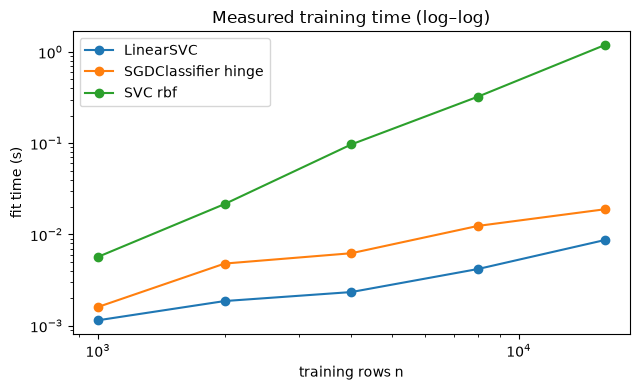

LinearSVC            empirical exponent: time ∝ n^0.95
SGDClassifier hinge  empirical exponent: time ∝ n^0.80
SVC rbf              empirical exponent: time ∝ n^1.81

Extrapolation from the fitted exponent (NOT measured — a lower bound, see below):
  n =  1,000,000: SVC ≈      0.6 h | a full float64 kernel matrix would need 8,000 GB
  n = 10,000,000: SVC ≈     37.4 h | a full float64 kernel matrix would need 800,000 GB
LinearSVC took 0.009 s at 16k rows. LIBSVM's 200 MB kernel cache already holds only ≈1,562 of 16,000 kernel rows;
the hit rate keeps falling as n grows, so real times at 1M rows would be worse than this extrapolation.


In [27]:
fig, ax = plt.subplots(figsize=(6.5, 4))
slopes = {}
for name, grp in timing.groupby("model"):
    ax.loglog(grp["n"], grp["fit s"], "o-", label=name)
    big = grp[grp["n"] >= 4000]                                  # small n is dominated by overhead
    slopes[name] = np.polyfit(np.log(big["n"]), np.log(big["fit s"]), 1)[0]
ax.set(xlabel="training rows n", ylabel="fit time (s)", title="Measured training time (log–log)")
ax.legend()
plt.tight_layout()
plt.show()
for name, s in slopes.items():
    print(f"{name:20s} empirical exponent: time ∝ n^{s:.2f}")

svc_16k = timing.query("model == 'SVC rbf' and n == 16000")["fit s"].item()
linear_16k = timing.query("model == 'LinearSVC' and n == 16000")["fit s"].item()
print("\nExtrapolation from the fitted exponent (NOT measured — a lower bound, see below):")
for big_n in [1_000_000, 10_000_000]:
    est_hours = svc_16k * (big_n / 16000) ** slopes["SVC rbf"] / 3600
    kernel_gb = big_n ** 2 * 8 / 1e9
    print(f"  n = {big_n:>10,}: SVC ≈ {est_hours:8.1f} h | a full float64 kernel matrix would need {kernel_gb:,.0f} GB")
rows_in_cache = 200e6 / (16000 * 8)                              # cache_size=200 MB, one float64 kernel row = n × 8 bytes
print(f"LinearSVC took {linear_16k:.3f} s at 16k rows. LIBSVM's 200 MB kernel cache already holds only ≈{rows_in_cache:,.0f} of 16,000 kernel rows;\n"
      "the hit rate keeps falling as n grows, so real times at 1M rows would be worse than this extrapolation.")

The linear models are ~100× faster but lose accuracy because this boundary is non-linear. A **kernel approximation** buys most of the accuracy back at linear-model speed:

In [28]:
start = time.perf_counter()
nystroem_svm = make_pipeline(StandardScaler(), Nystroem(kernel="rbf", gamma=0.1, n_components=500, random_state=0), LinearSVC())
nystroem_svm.fit(X_mg_pool, y_mg_pool)
ny_s = time.perf_counter() - start
print(f"Nystroem(500) + LinearSVC on all {len(y_mg_pool):,} rows: fit {ny_s:.2f} s | holdout acc {nystroem_svm.score(X_mg_hold, y_mg_hold):.3f}")

# SGD can also learn from a stream, one chunk at a time (data that doesn't fit in memory)
scaler_stream = StandardScaler().fit(X_mg_pool[:2000])         # in a real stream: statistics from an early sample
sgd_stream = SGDClassifier(loss="hinge", average=True, random_state=0)   # average=True: keep a running mean of the weights
X_hold_stream = scaler_stream.transform(X_mg_hold)
for n_pass in range(1, 6):                                      # each pass = the stream replayed once, in 8 chunks
    for chunk in np.array_split(np.random.default_rng(n_pass).permutation(len(y_mg_pool)), 8):
        sgd_stream.partial_fit(scaler_stream.transform(X_mg_pool[chunk]), y_mg_pool[chunk], classes=np.array([0, 1]))
    if n_pass in (1, 5):
        print(f"SGDClassifier(hinge) via partial_fit — after pass {n_pass}: holdout acc {sgd_stream.score(X_hold_stream, y_mg_hold):.3f}")
print("(one pass = one SGD epoch; averaging the iterates smooths out the noisy per-chunk updates, so even one pass is competitive)")

Nystroem(500) + LinearSVC on all 16,020 rows: fit 1.27 s | holdout acc 0.879
SGDClassifier(hinge) via partial_fit — after pass 1: holdout acc 0.781
SGDClassifier(hinge) via partial_fit — after pass 5: holdout acc 0.782
(one pass = one SGD epoch; averaging the iterates smooths out the noisy per-chunk updates, so even one pass is competitive)


**When an SVM is the wrong choice:**
- **> ~50–100k rows with a kernel** — time and kernel memory explode (measured above). Use a linear SVM, a kernel approximation, or gradient boosting.
- **Mixed tabular data** with categoricals, missing values, and different units — gradient-boosted trees ([10 · Gradient Boosting](10_Gradient_Boosting.ipynb)) need far less preprocessing and usually win.
- **You need probabilities or explanations** out of the box — logistic regression or trees are simpler to calibrate and explain.
- **Images, audio, raw text at scale** — deep learning learns the features; kernels on raw pixels don't.
- **Many irrelevant features** — the RBF distance gets diluted (section 6).

> 💡 **Interview angle:** "Why don't kernel SVMs scale?" — training needs (a large part of) the $n\times n$ kernel matrix: memory $O(n^2)$ and time between $O(n^2)$ and $O(n^3)$; prediction costs one kernel evaluation per support vector, and the number of SVs grows with $n$. Fixes: linear SVM (LIBLINEAR/SGD), Nyström or random Fourier features, subsampling, or a different model.

## 11. Head-to-Head on Real Data 🟡

A fair comparison uses **the same CV folds, the same preprocessing, and reports time**. Breast-cancer training split (the test split stays untouched), each model with sensible defaults inside a scaling pipeline:

In [29]:
from sklearn.naive_bayes import GaussianNB

contenders = {
    "SVC rbf": make_pipeline(StandardScaler(), SVC()),
    "LinearSVC": make_pipeline(StandardScaler(), LinearSVC()),
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "KNN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "GaussianNB": make_pipeline(StandardScaler(), GaussianNB()),
}
h2h_rows = []
for name, est in contenders.items():
    res = cross_validate(est, X_bc_tr, y_bc_tr, cv=cv5, scoring="accuracy")
    h2h_rows.append({"model": name, "CV acc mean": res["test_score"].mean(), "CV acc std": res["test_score"].std(),
                     "fit ms": res["fit_time"].mean() * 1000, "predict ms": res["score_time"].mean() * 1000})
h2h = pd.DataFrame(h2h_rows).sort_values("CV acc mean", ascending=False).round(4)
print(h2h.to_string(index=False))

top, runner_up = h2h.iloc[0], h2h.iloc[1]
if top["CV acc mean"] - runner_up["CV acc mean"] < top["CV acc std"]:
    print(f"\n{top['model']} and {runner_up['model']} are within one fold-std ({top['CV acc std']:.3f}) — statistically a tie on 426 rows; "
          "prefer the simpler/faster/more interpretable one.")
else:
    print(f"\n{top['model']} leads {runner_up['model']} by more than one fold-std.")

             model  CV acc mean  CV acc std  fit ms  predict ms
LogisticRegression       0.9789      0.0088  1.7920      0.3954
           SVC rbf       0.9671      0.0047  0.8959      0.4980
         KNN (k=5)       0.9671      0.0138  0.9604     19.1508
         LinearSVC       0.9648      0.0149  1.4058      0.7483
        GaussianNB       0.9319      0.0301  1.3968      0.4824

LogisticRegression leads SVC rbf by more than one fold-std.


> 💡 **Interview angle:** "SVM or logistic regression?" — both are linear classifiers with L2 regularization; they differ in loss (hinge vs log). Logistic regression gives probabilities and is easier to explain; linear SVMs can be slightly more robust to points far on the correct side. With a kernel, SVMs model non-linear boundaries that LR can't — at a much higher training cost.

## 12. One-Class SVM: a Pointer 🟢

`OneClassSVM` learns a boundary around **one** class ("normal" data) and flags points outside it as novelties; `nu` ≈ the fraction of training points allowed outside. A tiny real demo: train only on **benign** tumours, then see what it says about unseen benign and malignant ones. Anomaly detection gets its own notebook: [15 · Anomaly Detection](15_Anomaly_Detection.ipynb).

In [30]:
benign_tr = X_bc_tr[y_bc_tr == 1]
ocsvm = make_pipeline(StandardScaler(), OneClassSVM(nu=0.05, gamma="scale")).fit(benign_tr)
flag_benign = np.mean(ocsvm.predict(X_bc_te[y_bc_te == 1]) == -1)
flag_malig = np.mean(ocsvm.predict(X_bc_te[y_bc_te == 0]) == -1)
print(f"flagged as novel — unseen benign: {flag_benign:.1%} | malignant (never seen in training): {flag_malig:.1%}")

flagged as novel — unseen benign: 16.7% | malignant (never seen in training): 94.3%


## 🔧 Build It From Scratch

### 1) A linear SVM trained by sub-gradient descent (Pegasos-style)

The hinge loss has a kink at $m=1$, so we use a **sub-gradient** (any valid slope at the kink). With labels $y\in\{-1,+1\}$ and $\lambda = 1/(C\,n)$:

$$J(w)=\frac{\lambda}{2}\lVert w\rVert^2+\frac1n\sum_i\max(0,\,1-y_i\,w\cdot x_i), \qquad \partial J = \lambda w - \frac{1}{|B|}\sum_{i\in B,\ y_i w\cdot x_i<1} y_i x_i$$

**Pegasos** (Shalev-Shwartz et al.) takes mini-batch steps with learning rate $\eta_t = 1/(\lambda t)$, optionally projects $w$ onto a ball of radius $1/\sqrt\lambda$ (where the optimum must lie), and returns the **average** of the iterates for stability.

**Matching `LinearSVC` exactly:** `LinearSVC` adds a constant feature (`intercept_scaling=1`) and **regularizes the intercept** too. We do the same by appending a column of ones, and ask `LinearSVC` for the plain hinge loss (`loss="hinge"`; its default is squared hinge). Then both minimize the *same* strongly convex objective, so they must reach the same answer.

trained in 0.06 s
objective   ours 0.07809 | LinearSVC 0.07786 | relative gap +0.305%
test acc    ours 0.9860 | LinearSVC 0.9860
decision agreement 100.0% | correlation of scores 1.0000 | relative weight difference 0.039
✅ from-scratch Pegasos matches LinearSVC (objective within 1%, same accuracy, ≥98% identical decisions)


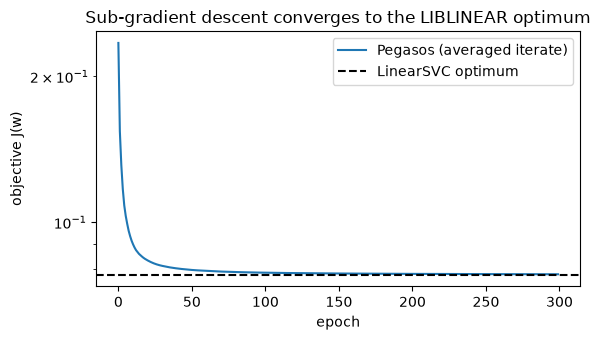

In [31]:
def add_bias_column(X):
    return np.column_stack([X, np.ones(len(X))])


def svm_objective(w, X, y, lam):
    return lam / 2 * w @ w + np.maximum(0, 1 - y * (X @ w)).mean()


def pegasos_fit(X, y, C, epochs=300, batch_size=16, seed=0):
    """Mini-batch Pegasos for the L2-regularized hinge loss. X already includes the bias column; y in {-1, +1}."""
    gen = np.random.default_rng(seed)
    n, d = X.shape
    lam = 1.0 / (C * n)
    w, w_avg, t = np.zeros(d), np.zeros(d), 0
    history = []
    for _ in range(epochs):
        for batch in np.array_split(gen.permutation(n), n // batch_size):
            t += 1
            eta = 1.0 / (lam * t)
            violators = y[batch] * (X[batch] @ w) < 1                    # inside the margin or wrong side
            subgrad = lam * w - (y[batch][violators] @ X[batch][violators]) / len(batch)
            w = w - eta * subgrad
            w *= min(1.0, (1 / np.sqrt(lam)) / (np.linalg.norm(w) + 1e-12))  # projection step
            w_avg += (w - w_avg) / t                                      # running average of iterates
        history.append(svm_objective(w_avg, X, y, lam))
    return w_avg, np.array(history)


bc_scaler = StandardScaler().fit(X_bc_tr)
Xs_tr, Xs_te = bc_scaler.transform(X_bc_tr), bc_scaler.transform(X_bc_te)
ypm_tr, ypm_te = np.where(y_bc_tr == 1, 1, -1), np.where(y_bc_te == 1, 1, -1)   # +1 = benign = classes_[1]

C_scratch = 0.1
start = time.perf_counter()
w_ours, obj_history = pegasos_fit(add_bias_column(Xs_tr), ypm_tr, C=C_scratch)
ours_s = time.perf_counter() - start
sk_linear = LinearSVC(C=C_scratch, loss="hinge", dual=True, tol=1e-8, max_iter=200_000).fit(Xs_tr, y_bc_tr)
w_sk = np.r_[sk_linear.coef_.ravel(), sk_linear.intercept_]

lam = 1 / (C_scratch * len(ypm_tr))
obj_ours, obj_sk = svm_objective(w_ours, add_bias_column(Xs_tr), ypm_tr, lam), svm_objective(w_sk, add_bias_column(Xs_tr), ypm_tr, lam)
dec_ours, dec_sk = add_bias_column(Xs_te) @ w_ours, sk_linear.decision_function(Xs_te)
acc_ours, acc_sk = np.mean(np.where(dec_ours > 0, 1, -1) == ypm_te), sk_linear.score(Xs_te, y_bc_te)
agreement = np.mean(np.sign(dec_ours) == np.sign(dec_sk))

print(f"trained in {ours_s:.2f} s")
print(f"objective   ours {obj_ours:.5f} | LinearSVC {obj_sk:.5f} | relative gap {(obj_ours - obj_sk) / obj_sk:+.3%}")
print(f"test acc    ours {acc_ours:.4f} | LinearSVC {acc_sk:.4f}")
print(f"decision agreement {agreement:.1%} | correlation of scores {np.corrcoef(dec_ours, dec_sk)[0, 1]:.4f} | "
      f"relative weight difference {np.linalg.norm(w_ours - w_sk) / np.linalg.norm(w_sk):.3f}")
assert abs(obj_ours - obj_sk) / obj_sk < 0.01, "objective should be within 1% of LinearSVC"
assert abs(acc_ours - acc_sk) <= 0.01 and agreement >= 0.98
print("✅ from-scratch Pegasos matches LinearSVC (objective within 1%, same accuracy, ≥98% identical decisions)")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(obj_history, label="Pegasos (averaged iterate)")
ax.axhline(obj_sk, color="k", ls="--", label="LinearSVC optimum")
ax.set(xlabel="epoch", ylabel="objective J(w)", yscale="log", title="Sub-gradient descent converges to the LIBLINEAR optimum")
ax.legend()
plt.tight_layout()
plt.show()

### 2) The RBF kernel matrix, vectorized

$K_{ij} = \exp(-\gamma\lVert a_i - b_j\rVert^2)$ with the expansion $\lVert a-b\rVert^2 = \lVert a\rVert^2+\lVert b\rVert^2-2\,a\cdot b$ (no Python loops, an $n\times m$ result).

In [32]:
def rbf_kernel_np(A, B, gamma):
    sq = (A ** 2).sum(axis=1)[:, None] + (B ** 2).sum(axis=1)[None, :] - 2 * A @ B.T
    return np.exp(-gamma * np.maximum(sq, 0.0))          # clip tiny negative rounding errors


K_ours = rbf_kernel_np(Xs_tr, Xs_te, gamma=0.05)
K_sk = rbf_kernel(Xs_tr, Xs_te, gamma=0.05)
assert K_ours.shape == (len(Xs_tr), len(Xs_te))
assert np.allclose(K_ours, K_sk, atol=1e-12)
print(f"✅ RBF kernel matrix {K_ours.shape} equals sklearn.metrics.pairwise.rbf_kernel (max abs diff {np.abs(K_ours - K_sk).max():.1e})")
print(f"diagonal of K(X, X) is all ones: {np.allclose(np.diag(rbf_kernel_np(Xs_tr[:50], Xs_tr[:50], 0.05)), 1)}")

✅ RBF kernel matrix (426, 143) equals sklearn.metrics.pairwise.rbf_kernel (max abs diff 1.6e-15)
diagonal of K(X, X) is all ones: True


### 3) A kernel SVM's prediction, rebuilt from the dual

With our kernel and scikit-learn's learned $\alpha_i y_i$ (`dual_coef_`) and $b$ (`intercept_`): $f(x)=\sum_{i\in SV}\alpha_i y_i K(x_i,x)+b$.

In [33]:
rbf_svm = SVC(kernel="rbf", gamma=0.05, C=1.0).fit(Xs_tr, y_bc_tr)
f_ours = rbf_svm.dual_coef_.ravel() @ rbf_kernel_np(rbf_svm.support_vectors_, Xs_te, gamma=0.05) + rbf_svm.intercept_[0]
assert np.allclose(f_ours, rbf_svm.decision_function(Xs_te))
pred_ours = rbf_svm.classes_[(f_ours > 0).astype(int)]
assert np.array_equal(pred_ours, rbf_svm.predict(Xs_te))
print(f"✅ f(x) = Σ αᵢyᵢK(xᵢ, x) + b reproduces decision_function and predict for all {len(Xs_te)} test rows "
      f"using {len(rbf_svm.support_)} support vectors")

✅ f(x) = Σ αᵢyᵢK(xᵢ, x) + b reproduces decision_function and predict for all 143 test rows using 114 support vectors


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Scaling a prediction batch with its own statistics
In production, requests often arrive in small, *unrepresentative* batches. Re-fitting a scaler on the batch shifts every feature and silently breaks the model.

In [34]:
malignant_batch = X_bc_te[y_bc_te == 0]                                 # a batch that happens to be all malignant
model_pipe = make_pipeline(StandardScaler(), SVC()).fit(X_bc_tr, y_bc_tr)

wrong = model_pipe[-1].predict(StandardScaler().fit_transform(malignant_batch))   # ❌ batch statistics
right = model_pipe.predict(malignant_batch)                                        # ✅ training statistics
print(f"❌ scaler re-fit on the batch: {np.mean(wrong == 0):.1%} of malignant tumours detected")
print(f"✅ pipeline's training scaler: {np.mean(right == 0):.1%} of malignant tumours detected")

❌ scaler re-fit on the batch: 34.0% of malignant tumours detected
✅ pipeline's training scaler: 98.1% of malignant tumours detected


### ❌ Pitfall 2 — Thresholding `decision_function` at 0.5
SVM scores are signed distances, not probabilities: the boundary is at **0**.

In [35]:
scores = model_pipe.decision_function(X_bc_te)
print(f"❌ scores ≥ 0.5 → accuracy {np.mean((scores >= 0.5).astype(int) == y_bc_te):.3f}")
print(f"✅ scores > 0 (what predict does) → accuracy {np.mean((scores > 0).astype(int) == y_bc_te):.3f}")
print("   Need probabilities? Calibrate (section 8) and threshold those.")

❌ scores ≥ 0.5 → accuracy 0.930
✅ scores > 0 (what predict does) → accuracy 0.979
   Need probabilities? Calibrate (section 8) and threshold those.


### ❌ Pitfall 3 — Reading `coef_` from a kernel SVM
Only linear kernels have weights per feature. For RBF the "weights" live in an infinite-dimensional space.

In [36]:
try:
    model_pipe[-1].coef_                                                   # ❌
except AttributeError as err:
    print("❌ AttributeError:", err)

from sklearn.inspection import permutation_importance

perm = permutation_importance(model_pipe, X_bc_te, y_bc_te, n_repeats=10, random_state=SEED)   # ✅ model-agnostic
top3 = np.argsort(perm.importances_mean)[::-1][:3]
print("✅ permutation importance, top 3:", [(str(cancer.feature_names[i]), round(float(perm.importances_mean[i]), 4)) for i in top3])

❌ AttributeError: coef_ is only available when using a linear kernel


✅ permutation importance, top 3: [('worst texture', 0.0259), ('worst smoothness', 0.0147), ('worst radius', 0.014)]


### ❌ Pitfall 4 — Assuming `LinearSVC` is the same model as `SVC(kernel="linear")`
`LinearSVC` defaults to **squared hinge** loss and **regularizes the intercept**; `SVC(kernel="linear")` uses hinge loss with a free intercept. Same family, different optimum.

In [37]:
svc_lin = SVC(kernel="linear", C=1.0).fit(Xs_tr, y_bc_tr)
lsvc_default = LinearSVC(C=1.0).fit(Xs_tr, y_bc_tr)
rel_diff = np.linalg.norm(svc_lin.coef_ - lsvc_default.coef_) / np.linalg.norm(svc_lin.coef_)
print(f"❌ 'identical' models: relative coefficient difference {rel_diff:.1%}, intercepts {svc_lin.intercept_[0]:.3f} vs {lsvc_default.intercept_[0]:.3f}, "
      f"test predictions differ on {np.mean(svc_lin.predict(Xs_te) != lsvc_default.predict(Xs_te)):.1%} of rows")
print("✅ pick one on purpose: LinearSVC for speed on large n, SVC(kernel='linear') when you need support vectors / the dual;"
      " set loss='hinge' if you want LinearSVC's objective to match")

❌ 'identical' models: relative coefficient difference 58.9%, intercepts -0.010 vs -0.231, test predictions differ on 1.4% of rows
✅ pick one on purpose: LinearSVC for speed on large n, SVC(kernel='linear') when you need support vectors / the dual; set loss='hinge' if you want LinearSVC's objective to match


### ❌ Pitfall 5 — Feeding raw features to `SGDClassifier`
SGD uses one learning-rate schedule for every weight; features on wildly different scales make it bounce around.

In [38]:
sgd_raw = SGDClassifier(loss="hinge", random_state=0).fit(X_bc_tr, y_bc_tr)                                  # ❌ areas ~1000s next to ratios ~0.01
sgd_scaled = make_pipeline(StandardScaler(), SGDClassifier(loss="hinge", random_state=0)).fit(X_bc_tr, y_bc_tr)  # ✅
print(f"❌ raw features   : test acc {sgd_raw.score(X_bc_te, y_bc_te):.3f}")
print(f"✅ StandardScaler : test acc {sgd_scaled.score(X_bc_te, y_bc_te):.3f}")

❌ raw features   : test acc 0.881
✅ StandardScaler : test acc 0.958


### ❌ Pitfall 6 — Ignoring class imbalance
The hinge loss counts every violation equally, so a rare class gets pushed aside. Real example: detect the digit **8** (≈10% of digits) with a linear SVM.

In [39]:
y_is8 = (y_dig == 8).astype(int)
Xd_tr, Xd_te, y8_tr, y8_te = train_test_split(X_dig, y_is8, test_size=0.3, stratify=y_is8, random_state=SEED)
from sklearn.metrics import precision_score, recall_score

for label, cw in [("❌ class_weight=None      ", None), ("✅ class_weight='balanced'", "balanced")]:
    pred8 = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1, class_weight=cw)).fit(Xd_tr, y8_tr).predict(Xd_te)
    print(f"{label}: recall of 8s {recall_score(y8_te, pred8):.3f} | precision {precision_score(y8_te, pred8):.3f}")
print("   'balanced' scales C per class by n / (2·n_class): missed 8s now cost more — choose based on the cost of each error type.")

❌ class_weight=None      : recall of 8s 0.615 | precision 0.889
✅ class_weight='balanced': recall of 8s 0.769 | precision 0.702
   'balanced' scales C per class by n / (2·n_class): missed 8s now cost more — choose based on the cost of each error type.


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Hinge loss by hand
For functional margins `m = [-0.5, 0.5, 1.0, 2.5]`, compute the hinge losses as an array `hinge_values`.

In [40]:
m_values = np.array([-0.5, 0.5, 1.0, 2.5])
hinge_values = None  # TODO
check("hinge_values", hinge_values, [1.5, 0.5, 0.0, 0.0], hint="np.maximum(0, 1 - m)")

⏳ hinge_values: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
m_values = np.array([-0.5, 0.5, 1.0, 2.5])
hinge_values = np.maximum(0, 1 - m_values)
check("hinge_values", hinge_values, [1.5, 0.5, 0.0, 0.0])
```
Points with m ≥ 1 are safely outside the margin and contribute nothing — the source of SVM sparsity.
</details>

### 🟢 Exercise 2 — Margin width
A linear SVM learned `w = [3, 4]`. Store the margin width in `margin_w`.

In [41]:
w_given = np.array([3.0, 4.0])
margin_w = None  # TODO
check("margin_w", margin_w, 0.4, hint="2 / ||w||, and ||[3, 4]|| = 5.")

⏳ margin_w: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
w_given = np.array([3.0, 4.0])
margin_w = 2 / np.linalg.norm(w_given)
check("margin_w", margin_w, 0.4)
```
</details>

### 🟢 Exercise 3 — How many binary models?
For a problem with 7 classes, store `[n_ovo_models, n_ovr_models]` in `n_models`.

In [42]:
n_classes = 7
n_models = None  # TODO
check("n_models", n_models, [21, 7], hint="OvO: k(k−1)/2 pairs. OvR: one per class.")

⏳ n_models: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_classes = 7
n_models = [n_classes * (n_classes - 1) // 2, n_classes]
check("n_models", n_models, [21, 7])
```
</details>

### 🟡 Exercise 4 — Polynomial kernel matrix, vectorized
Compute the kernel matrix $K_{ij} = (\gamma\,a_i\cdot b_j + r)^d$ between `A_poly` (5 rows) and `B_poly` (3 rows) with `gamma=0.1`, `coef0=1`, `degree=2` — no loops. Store it in `K_poly`.

In [43]:
A_poly, B_poly = Xs_tr[:5], Xs_te[:3]
K_poly = None  # TODO
check("K_poly", K_poly, polynomial_kernel(A_poly, B_poly, degree=2, gamma=0.1, coef0=1),
      hint="A_poly @ B_poly.T gives all dot products at once (shape 5×3).")

⏳ K_poly: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
A_poly, B_poly = Xs_tr[:5], Xs_te[:3]
K_poly = (0.1 * (A_poly @ B_poly.T) + 1) ** 2
check("K_poly", K_poly, polynomial_kernel(A_poly, B_poly, degree=2, gamma=0.1, coef0=1))
```
</details>

### 🟡 Exercise 5 — One Pegasos step
Starting from `w0`, take **one** mini-batch sub-gradient step on the batch `Xb, yb` with `lam = 0.1` at iteration `t = 10` (so $\eta = 1/(\lambda t) = 1$). No projection. Store the new weights in `w1`.

In [44]:
w0 = np.array([0.5, -0.5])
Xb = np.array([[1.0, 2.0], [2.0, -1.0], [-1.0, 1.0]])
yb = np.array([1, -1, 1])
lam_ex, t_ex = 0.1, 10
w1 = None  # TODO
check("w1", w1, [0.5 - (0.1 * 0.5 + 2 / 3), -0.5 - (0.1 * -0.5 - 4 / 3)],
      hint="violators = yb * (Xb @ w0) < 1; grad = lam*w0 - (yb[v] @ Xb[v]) / len(yb); w1 = w0 - eta*grad")

⏳ w1: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
w0 = np.array([0.5, -0.5])
Xb = np.array([[1.0, 2.0], [2.0, -1.0], [-1.0, 1.0]])
yb = np.array([1, -1, 1])
lam_ex, t_ex = 0.1, 10
eta = 1 / (lam_ex * t_ex)
violators = yb * (Xb @ w0) < 1                      # all three rows violate the margin here
grad = lam_ex * w0 - (yb[violators] @ Xb[violators]) / len(yb)
w1 = w0 - eta * grad
check("w1", w1, [0.5 - (0.1 * 0.5 + 2 / 3), -0.5 - (0.1 * -0.5 - 4 / 3)])
```
Divide by the **batch size** (3), not by the number of violators — the loss is an average over the batch.
</details>

### 🔴 Exercise 6 — One-vs-one voting (interview-style)
`ovo_model` (section 7) was fitted on all digits with `decision_function_shape="ovo"`. Its `decision_function` returns 45 columns, one per class pair in the order `combinations(range(10), 2)` = (0,1), (0,2), …, (8,9). A **positive** value is a vote for the **first** class of the pair. Reproduce `ovo_model.predict(X_dig)` from these scores by counting votes (ties go to the lower class index). Store the predictions in `ovo_predictions`.

In [45]:
D_ovo = ovo_model.decision_function(X_dig)               # shape (1797, 45)
ovo_predictions = None  # TODO
check("ovo_predictions", ovo_predictions, ovo_model.predict(X_dig),
      hint="votes = zeros((n, 10)); for each pair k=(i, j): winner = where(D[:, k] > 0, i, j); add 1 to votes[row, winner]; argmax.")

⏳ ovo_predictions: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
D_ovo = ovo_model.decision_function(X_dig)
votes = np.zeros((len(X_dig), 10), dtype=int)
rows = np.arange(len(X_dig))
for k, (i, j) in enumerate(combinations(range(10), 2)):
    winner = np.where(D_ovo[:, k] > 0, i, j)
    np.add.at(votes, (rows, winner), 1)
ovo_predictions = votes.argmax(axis=1)                 # argmax returns the first (lowest) class on ties
check("ovo_predictions", ovo_predictions, ovo_model.predict(X_dig))
```
`np.add.at` is the safe way to increment with repeated indices; here each row appears once per pair, so `votes[rows, winner] += 1` also works.
</details>

## 🚀 Mini Project: Gamma-Ray or Hadron? Choosing a Classifier

**Goal:** the MAGIC gamma-ray telescope records flashes of light in the atmosphere. Most are **hadron** background; the interesting ones are **gamma rays**. Pick the model the telescope team should deploy — a tuned **RBF SVM**, **logistic regression**, or **KNN** — using the *same* CV folds, measuring fit and predict time, and touching the test set **once**.

**Steps:** split → tuning budget → tune each model with identical folds → compare CV score and cost → compute a recommendation → one test evaluation.

### Step 1 — Split once, keep the test set locked

In [46]:
X_proj_tr, X_proj_te, y_proj_tr, y_proj_te = train_test_split(X_magic, y_magic, test_size=0.25, stratify=y_magic, random_state=SEED)
print(f"train {X_proj_tr.shape[0]:,} rows | test {X_proj_te.shape[0]:,} rows (locked) | gamma share train {y_proj_tr.mean():.3f}")

# Tuning budget: an RBF grid search on all ~14k rows × 5 folds × 12 settings would take minutes (section 10),
# so we tune on a stratified 6,000-row sample of the TRAINING set, then refit the winner on the full training set.
tune_idx, _ = train_test_split(np.arange(len(y_proj_tr)), train_size=6000, stratify=y_proj_tr, random_state=SEED)
X_tune, y_tune = X_proj_tr[tune_idx], y_proj_tr[tune_idx]
proj_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)     # the SAME folds for every model
print(f"tuning sample: {len(y_tune):,} rows, 5 stratified folds shared by all models")

train 14,265 rows | test 4,755 rows (locked) | gamma share train 0.648
tuning sample: 6,000 rows, 5 stratified folds shared by all models


### Step 2 — Tune each model on identical folds

In [47]:
searches = {
    "RBF SVM": (make_pipeline(StandardScaler(), SVC()),
                {"svc__C": [30, 100, 300, 1000], "svc__gamma": [0.01, 0.03, 0.1]}),
    "Logistic regression": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
                            {"logisticregression__C": [0.01, 0.1, 1, 10]}),
    "KNN": (make_pipeline(StandardScaler(), KNeighborsClassifier()),
            {"kneighborsclassifier__n_neighbors": [5, 15, 31, 61], "kneighborsclassifier__weights": ["uniform", "distance"]}),
}
fitted_searches, tune_rows = {}, []
for name, (pipe, grid) in searches.items():
    start = time.perf_counter()
    gs = GridSearchCV(pipe, grid, cv=proj_cv, scoring="accuracy", n_jobs=1).fit(X_tune, y_tune)
    search_s = time.perf_counter() - start
    best_i = gs.best_index_
    edge = any(gs.best_params_[k] in (v[0], v[-1]) for k, v in grid.items() if not isinstance(v[0], str))
    fitted_searches[name] = gs
    tune_rows.append({"model": name, "best params": gs.best_params_, "CV acc": gs.best_score_,
                      "CV std": gs.cv_results_["std_test_score"][best_i], "fit s (per fold)": gs.cv_results_["mean_fit_time"][best_i],
                      "predict s (per fold)": gs.cv_results_["mean_score_time"][best_i], "search s": search_s, "on grid edge": edge})
tune_df = pd.DataFrame(tune_rows)
with pd.option_context("display.max_colwidth", 70):
    print(tune_df.round(4).to_string(index=False))

              model                                                                            best params  CV acc  CV std  fit s (per fold)  predict s (per fold)  search s  on grid edge
            RBF SVM                                                    {'svc__C': 100, 'svc__gamma': 0.03}  0.8650  0.0065            0.1935                0.0407   25.5123         False
Logistic regression                                                         {'logisticregression__C': 0.1}  0.7907  0.0099            0.0022                0.0003    0.0572         False
                KNN {'kneighborsclassifier__n_neighbors': 15, 'kneighborsclassifier__weights': 'distance'}  0.8262  0.0112            0.0015                0.0150    0.7861         False


### Step 3 — Compute the recommendation from the numbers

Decision rule (written **before** looking at the test set): take the best CV accuracy; if a **faster** model is within one fold-standard-deviation of it, prefer the faster one (cheaper to run and retrain).

In [48]:
ranked = tune_df.sort_values("CV acc", ascending=False).reset_index(drop=True)
leader = ranked.iloc[0]
tolerance = leader["CV std"]
cheaper_close = ranked[(ranked["CV acc"] >= leader["CV acc"] - tolerance)
                       & (ranked["predict s (per fold)"] + ranked["fit s (per fold)"] < leader["predict s (per fold)"] + leader["fit s (per fold)"])]
recommended = cheaper_close.iloc[0]["model"] if len(cheaper_close) else leader["model"]
print(f"CV leader: {leader['model']} ({leader['CV acc']:.4f} ± {tolerance:.4f})")
for _, row in ranked.iloc[1:].iterrows():
    print(f"  {row['model']:20s} {row['CV acc']:.4f} → {leader['CV acc'] - row['CV acc']:+.4f} behind "
          f"({(leader['CV acc'] - row['CV acc']) / tolerance:.1f} fold-stds)")
print(f"\n📌 Recommendation (decided on CV only): {recommended}")
if tune_df["on grid edge"].any():
    print("⚠️ some best parameters are on a grid edge:", tune_df.loc[tune_df["on grid edge"], "model"].tolist(), "— widen that grid in a stretch goal")

CV leader: RBF SVM (0.8650 ± 0.0065)
  KNN                  0.8262 → +0.0388 behind (6.0 fold-stds)
  Logistic regression  0.7907 → +0.0743 behind (11.4 fold-stds)

📌 Recommendation (decided on CV only): RBF SVM


### Step 4 — Refit on the full training set and evaluate on the test set once

In [49]:
final_rows = []
for name, gs in fitted_searches.items():
    model = gs.best_estimator_                      # clone of the best pipeline, refit on the full training set below
    start = time.perf_counter()
    model.fit(X_proj_tr, y_proj_tr)
    fit_s = time.perf_counter() - start
    start = time.perf_counter()
    test_pred = model.predict(X_proj_te)
    pred_ms_per_1k = (time.perf_counter() - start) * 1000 / len(X_proj_te) * 1000
    final_rows.append({"model": name, "test acc": accuracy_score(y_proj_te, test_pred), "fit s (14k rows)": fit_s,
                       "predict ms / 1k rows": pred_ms_per_1k})
final_df = pd.DataFrame(final_rows).round(4)
print(final_df.to_string(index=False))

majority_acc = max(y_proj_te.mean(), 1 - y_proj_te.mean())
rec_row = final_df.set_index("model").loc[recommended]
print(f"\nmajority-class baseline: {majority_acc:.4f}")
print(f"recommended model ({recommended}) test accuracy {rec_row['test acc']:.4f} "
      f"({rec_row['test acc'] - majority_acc:+.4f} vs baseline); predicting 1,000 events takes {rec_row['predict ms / 1k rows']:.1f} ms")

              model  test acc  fit s (14k rows)  predict ms / 1k rows
            RBF SVM    0.8744            1.6531              103.2161
Logistic regression    0.7819            0.0058                0.0472
                KNN    0.8408            0.0035               17.4619

majority-class baseline: 0.6484
recommended model (RBF SVM) test accuracy 0.8744 (+0.2260 vs baseline); predicting 1,000 events takes 103.2 ms


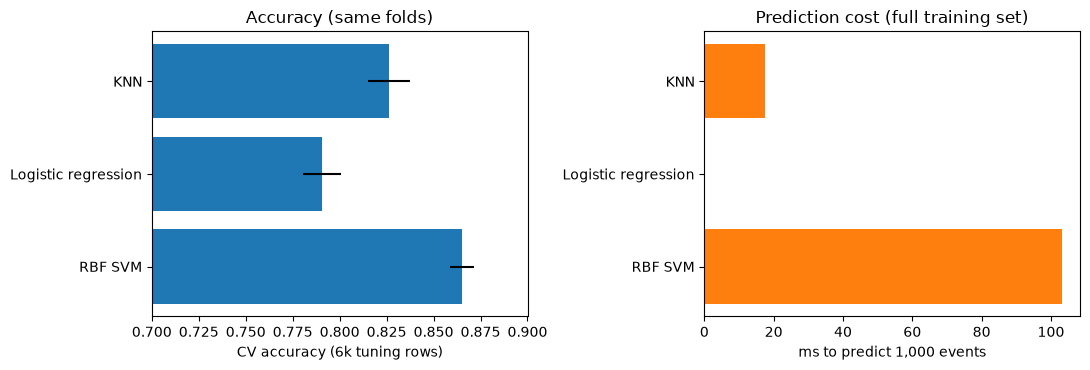

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].barh(tune_df["model"], tune_df["CV acc"], xerr=tune_df["CV std"], color="#1f77b4")
axes[0].set(xlim=(0.7, 0.9), xlabel="CV accuracy (6k tuning rows)", title="Accuracy (same folds)")
axes[1].barh(final_df["model"], final_df["predict ms / 1k rows"], color="#ff7f0e")
axes[1].set(xlabel="ms to predict 1,000 events", title="Prediction cost (full training set)")
plt.tight_layout()
plt.show()

**Stretch goals**
1. Widen any grid whose best value landed on an edge, and add a `Nystroem` + `LinearSVC` pipeline to the comparison — does it match the RBF SVM at a fraction of the prediction cost?
2. In gamma-ray astronomy a false "gamma" is expensive. Calibrate the SVM (`CalibratedClassifierCV(..., ensemble=False)`) and report the hadron contamination at a threshold chosen on validation data.
3. Replace accuracy with ROC-AUC in every search and check whether the recommendation changes.

### 🗣️ How to talk about this in an interview
- "I compared a tuned RBF SVM, logistic regression, and KNN on MagicTelescope with **identical stratified folds**, scaling inside each pipeline, and I measured fit and predict time, not only accuracy."
- "I wrote the decision rule down before looking at the test set: best CV accuracy, unless a cheaper model is within one fold-standard-deviation."
- "The RBF kernel's advantage over logistic regression tells me the boundary is non-linear; KNN also captures that but pays at prediction time because it stores the whole training set."
- "Kernel SVM training grew roughly quadratically in my timing experiment, so I tuned on a 6k-row sample and refit on all data — for millions of events I'd switch to a kernel approximation or gradient boosting."
- "I evaluated on the locked test set exactly once, and compared with the majority-class baseline."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Explain the kernel trick.**

<details><summary>Show answer</summary>

- **30-second answer:** In the SVM dual, the data appear only as dot products $x_i\cdot x_j$. Replacing them with a kernel $K(x_i,x_j)=\phi(x_i)\cdot\phi(x_j)$ gives a linear classifier in the (possibly infinite-dimensional) feature space of $\phi$ without ever computing $\phi$ — a non-linear boundary in the original space at the cost of kernel evaluations.
- **Go deeper:** A function is a valid kernel if every Gram matrix it produces is symmetric positive semi-definite (Mercer). RBF corresponds to an infinite-dimensional map. The cost is the $n\times n$ Gram matrix, which is why kernel methods struggle beyond ~100k rows; Nyström and random Fourier features approximate $\phi$ explicitly to regain linear scaling.
- **❌ Common wrong answer:** "The kernel trick transforms the data into higher dimensions before training." It avoids that transformation — that's the whole trick.

</details>

**Q2. What are support vectors, and why do they matter?**

<details><summary>Show answer</summary>

- **30-second answer:** Training points on or inside the margin (including misclassified ones) — exactly those with $\alpha_i>0$ in the dual. The decision function is a weighted sum over them only, so removing any other point leaves the model unchanged.
- **Go deeper:** $0<\alpha_i<C$ → on the margin; $\alpha_i=C$ → inside it or wrong side. The number of SVs drives prediction cost for kernel SVMs and is an upper bound hint on leave-one-out error (LOO error ≤ #SV / n).
- **❌ Common wrong answer:** "Support vectors are the points closest to the class centroids."

</details>

**Q3. What do `C` and `gamma` control in an RBF SVM?**

<details><summary>Show answer</summary>

- **30-second answer:** `C` is inverse regularization — how much margin violations cost (large `C` = narrow margin, fits training data hard). `gamma` is the inverse reach of each support vector (large `gamma` = very local bumps). Large values of either push towards overfitting; tune both together on a log grid with CV.
- **Go deeper:** They interact: a large `gamma` with small `C` can still be smooth-ish, and the good region is often a diagonal band in the C–gamma heatmap. `gamma="scale"` = $1/(n_\text{features}\cdot\operatorname{Var}(X))$ is a sensible centre for the grid once features are standardized.
- **❌ Common wrong answer:** "Larger `C` means more regularization" (that's `alpha`/`λ`; `C` is the inverse).

</details>

**Q4. Compare hinge loss and log loss. When would you pick an SVM over logistic regression?**

<details><summary>Show answer</summary>

- **30-second answer:** Hinge $\max(0,1-m)$ is exactly zero for confidently correct points, giving sparse solutions and a max-margin boundary but no probabilities; log loss $\log(1+e^{-m})$ never reaches zero, so every point matters, and it yields calibrated-ish probabilities. Pick an SVM for a non-linear kernel boundary on small/medium data or when margin robustness matters; pick logistic regression when you need probabilities, interpretability, or huge data.
- **Go deeper:** With linear models and good regularization the two usually score within noise of each other. Hinge is not differentiable at 1 (use sub-gradients); squared hinge (LinearSVC default) is differentiable. Both are convex upper bounds of the 0–1 loss.
- **❌ Common wrong answer:** "SVMs are always more accurate than logistic regression."

</details>

**Q5. What is the difference between the primal and dual SVM problems, and why solve the dual?**

<details><summary>Show answer</summary>

- **30-second answer:** The primal optimizes $d$ weights (one per feature) with margin constraints; the dual optimizes $n$ multipliers $\alpha_i$ (one per row) subject to $0\le\alpha_i\le C$ and $\sum\alpha_i y_i=0$. The dual depends on data only through dot products (→ kernels) and is sparse in $\alpha$.
- **Go deeper:** Strong duality holds (convex QP satisfying Slater's condition), so both give the same solution; KKT conditions link them: $w=\sum\alpha_i y_i x_i$. Choose primal (LIBLINEAR / SGD) when $n\gg d$ and linear; dual (LIBSVM SMO) for kernels. LinearSVC's `dual="auto"` picks based on the shape and loss.
- **❌ Common wrong answer:** "The dual is an approximation of the primal."

</details>

**Q6. Why is feature scaling mandatory for SVMs but not for decision trees?**

<details><summary>Show answer</summary>

- **30-second answer:** SVMs measure margins and RBF distances in raw units, so a large-scale feature dominates (on wine, `proline` supplied 99.8% of the squared distance and accuracy dropped from 0.98 to 0.67 unscaled). Trees only compare a feature with a threshold, which any monotone rescaling preserves.
- **Go deeper:** Fit the scaler inside the CV `Pipeline`; for sparse text use `MaxAbsScaler` or normalized TF-IDF to keep sparsity. Scaling fixes units, not relevance — irrelevant features still dilute the RBF distance.
- **❌ Common wrong answer:** "Scaling only speeds up convergence."

</details>

**Q7. How does SVR work and what does epsilon control?**

<details><summary>Show answer</summary>

- **30-second answer:** SVR fits a function with a tube of half-width ε; errors inside the tube cost nothing, errors outside cost linearly, plus an L2 penalty for flatness. Larger ε → fewer support vectors and a simpler model; ε is in target units.
- **Go deeper:** It's the regression analogue of the soft margin with the ε-insensitive loss, which makes it more robust to outliers than least squares. `C` trades flatness against tube violations; like SVC, kernel SVR scales poorly with $n$.
- **❌ Common wrong answer:** "Epsilon is the learning rate."

</details>

### 💻 Coding

**Q8. Implement a linear SVM without libraries.**

<details><summary>Show answer</summary>

- **30-second answer:** Minimize $\frac\lambda2\lVert w\rVert^2+\frac1n\sum\max(0,1-y_i w\cdot x_i)$ by sub-gradient descent: for a mini-batch, `v = y*(X@w) < 1; grad = lam*w - (y[v] @ X[v]) / len(y); w -= eta*grad` with `eta = 1/(lam*t)` (Pegasos), averaging iterates. Add a bias column; labels must be ±1; standardize features.
- **Go deeper:** Pegasos converges in $\tilde O(1/(\lambda\varepsilon))$ iterations independent of $n$. Verify against `LinearSVC(loss="hinge")` by comparing the objective value — remember LinearSVC also regularizes the intercept.
- **❌ Common wrong answer:** Using 0/1 labels in the hinge, or dividing the gradient by the number of violators instead of the batch size.

</details>

**Q9. Compute an RBF kernel matrix between two sets of points efficiently.**

<details><summary>Show answer</summary>

- **30-second answer:** `sq = (A**2).sum(1)[:, None] + (B**2).sum(1)[None, :] - 2*A@B.T; K = np.exp(-gamma*np.maximum(sq, 0))` — $O(nm)$ memory, BLAS-fast.
- **Go deeper:** Clip negatives from rounding; for very large sets compute in chunks. For prediction you only need $K$ between test rows and support vectors.
- **❌ Common wrong answer:** A double Python loop, or broadcasting `A[:, None, :] - B[None]`, which allocates $n\cdot m\cdot d$ floats.

</details>

### 🐛 Debugging Scenarios

**Q10. Your RBF SVM gets 100% training accuracy and 60% validation accuracy. What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** It's memorizing: `gamma` and/or `C` too large. Check scaling first (an unscaled large feature makes the effective reach tiny in other directions), then search `C` and `gamma` on log grids with CV; look at the fraction of support vectors (near 100% signals overfitting or overlap).
- **Go deeper:** Our wine grid showed C=1000, γ=10 hitting 1.00 train accuracy with a lower CV score. Also consider removing irrelevant features and checking for duplicated rows across splits.
- **❌ Common wrong answer:** "Increase `C` to regularize more."

</details>

**Q11. Training `SVC` on 2 million rows has been running for hours. What are your options?**

<details><summary>Show answer</summary>

- **30-second answer:** Kernel SVC is ~$O(n^2)$ or worse — measured here as roughly quadratic. Use `LinearSVC` or `SGDClassifier(loss="hinge")` if a linear boundary is enough; `Nystroem`/`RBFSampler` + a linear SVM to approximate the kernel; tune on a subsample; or switch to gradient boosting for tabular data.
- **Go deeper:** Increasing `cache_size` helps moderately; GPU implementations (cuML, ThunderSVM) help more. Prediction also slows as the number of support vectors grows with $n$.
- **❌ Common wrong answer:** "Add `n_jobs=-1`" — `SVC` has no `n_jobs`; LIBSVM training is single-threaded.

</details>

**Q12. After upgrading scikit-learn, `SVC(probability=True)` prints a FutureWarning. What changed and what do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** In scikit-learn 1.9 the `probability` parameter (and `probA_`/`probB_`) was deprecated, to be removed in 1.11. Replace it with `CalibratedClassifierCV(SVC(), ensemble=False)` (Platt/sigmoid on out-of-fold scores), or `CalibratedClassifierCV(FrozenEstimator(fitted_svc)).fit(X_calib, y_calib)` for an already-fitted model.
- **Go deeper:** Calibrated `predict_proba` can disagree with `predict()` near the boundary — choose one decision rule. Evaluate calibration with log loss/Brier and a reliability curve on held-out data; use isotonic only with enough calibration rows.
- **❌ Common wrong answer:** "Apply a sigmoid to `decision_function`" — that is not calibrated (our test log loss was 0.25 vs 0.08 for Platt).

</details>

### 🏗️ Design

**Q13. You're building a spam filter over 5 million emails with a 1-million-term TF-IDF vocabulary. Which SVM setup?**

<details><summary>Show answer</summary>

- **30-second answer:** A **linear** SVM on sparse features: `LinearSVC` or `SGDClassifier(loss="hinge")` with `partial_fit` for streaming updates. Text is high-dimensional and nearly linearly separable, so kernels add cost without much gain.
- **Go deeper:** Keep inputs sparse (no dense scaling), tune `C`/`alpha` on log scale, calibrate with `CalibratedClassifierCV` if you need a spam probability for thresholds, handle imbalance with `class_weight`, and monitor drift. Compare against logistic regression and a small transformer baseline if latency allows.
- **❌ Common wrong answer:** "RBF SVM, because kernels are more powerful."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** A linear SVM has `w = [0.6, 0.8]`. What is its margin width?
<details><summary>Answer</summary>

`2.0` — $\lVert w\rVert = 1$, and the width is $2/\lVert w\rVert$.
</details>

**2.** `np.maximum(0, 1 - np.array([2.0, 1.0, 0.0]))`
<details><summary>Answer</summary>

`array([0., 0., 1.])` — the hinge is zero at and beyond margin 1.
</details>

**3.** `SVC()` on 10 classes with `decision_function_shape="ovo"`: how many columns does `decision_function` return?
<details><summary>Answer</summary>

`45` — one per class pair, $10\cdot 9/2$ (verified in section 7).
</details>

**4.** `rbf_kernel([[0, 0]], [[1, 1]], gamma=0.5)`
<details><summary>Answer</summary>

`array([[0.3679]])` — $\exp(-0.5\cdot 2) = e^{-1}$.
</details>

**5.** You increase SVR's `epsilon` from 0.25 to 1.0. Do the support vectors increase or decrease?
<details><summary>Answer</summary>

**Decrease** — more points fit inside the wider tube, where $\alpha_i=0$ (section 9's table shows the drop).
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html) — kernels, multiclass, SVR, complexity, and the exact formulations used by `SVC`, `LinearSVC`, and `SVR`
- [scikit-learn — Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) — `CalibratedClassifierCV`, Platt vs isotonic, `FrozenEstimator`
- [scikit-learn — Kernel Approximation](https://scikit-learn.org/stable/modules/kernel_approximation.html) — Nyström and random Fourier features for large data
- [scikit-learn — Stochastic Gradient Descent](https://scikit-learn.org/stable/modules/sgd.html) — `SGDClassifier(loss="hinge")`, `partial_fit`, practical tips

### 🎥 Videos
- [StatQuest — Support Vector Machines Part 1 (of 3): Main Ideas!!!](https://www.youtube.com/watch?v=efR1C6CvhmE) — Josh Starmer on maximal margin, soft margins, and support vectors; watch before section 1
- [StatQuest — Support Vector Machines Part 2: The Polynomial Kernel (Part 2 of 3)](https://www.youtube.com/watch?v=Toet3EiSFcM) — the dot-product view of the polynomial kernel, matching our φ(x)·φ(z) proof
- [StatQuest — Support Vector Machines Part 3: The Radial (RBF) Kernel (Part 3 of 3)](https://www.youtube.com/watch?v=Qc5IyLW_hns) — why RBF behaves like a weighted nearest neighbour in infinite dimensions

### 📄 Papers
- [Cortes & Vapnik (1995) — Support-Vector Networks](https://link.springer.com/article/10.1007/BF00994018) — the soft-margin SVM paper
- [Shalev-Shwartz, Singer, Srebro & Cotter — Pegasos: Primal Estimated sub-GrAdient SOlver for SVM](https://home.ttic.edu/~nati/Publications/PegasosMPB.pdf) — the algorithm behind our from-scratch build
- [Hsu, Chang & Lin — A Practical Guide to Support Vector Classification](https://www.csie.ntu.edu.tw/~cjlin/papers/guide/guide.pdf) — the LIBSVM authors' recipe: scale, RBF, log-grid search on C and gamma
- [Rahimi & Recht (2007) — Random Features for Large-Scale Kernel Machines](https://papers.nips.cc/paper/3182-random-features-for-large-scale-kernel-machines) — how to approximate kernels with explicit features

### 📘 Books & Courses
- [An Introduction to Statistical Learning](https://www.statlearning.com/) — free PDF (with a Python edition); chapter 9 covers maximal-margin classifiers, SVMs, and kernels gently
- [The Elements of Statistical Learning (2nd ed.)](https://hastie.su.domains/ElemStatLearn/) — chapter 12 for the full optimization view

### 🏋️ Practice
- [Deep-ML — Practice Machine Learning](https://www.deep-ml.com/) — implement Pegasos, kernels, and other algorithms from scratch, interview-style

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Maximum margin | widest street between classes | margin $=2/\lVert w\rVert$ · `SVC(kernel="linear").coef_` |
| Support vectors | the only points that define the model | $\alpha_i>0$ · `support_`, `n_support_`, `dual_coef_` |
| Soft margin `C` | cost of margin violations (inverse regularization) | $\tfrac12\lVert w\rVert^2 + C\sum\xi_i$ · tune on log scale |
| Hinge loss | zero beyond margin 1 → sparse, no probabilities | $\max(0,1-y f(x))$ vs log loss $\log(1+e^{-yf})$ |
| Primal vs dual | $d$ weights vs $n$ multipliers; dual → kernels | $w=\sum\alpha_i y_i x_i$ · $0\le\alpha_i\le C$ |
| Kernels | non-linear boundary via dot products | poly $(\gamma x\cdot z+r)^d$ · RBF $e^{-\gamma\lVert x-z\rVert^2}$ |
| `gamma` | reach of each support vector | `"scale"` = $1/(d\cdot\operatorname{Var}X)$ · large → overfit |
| Scaling | required for margins and distances | `make_pipeline(StandardScaler(), SVC())` |
| Multiclass | OvO (SVC) vs OvR (LinearSVC) | $k(k-1)/2$ vs $k$ models · `decision_function_shape` |
| Probabilities | Platt / isotonic on held-out scores | `CalibratedClassifierCV(SVC(), ensemble=False)` · `probability=True` deprecated in 1.9 |
| SVR | ε-insensitive tube regression | `SVR(C, epsilon, gamma)` · wider ε → fewer SVs |
| Big data | linear or approximate kernels | `LinearSVC`, `SGDClassifier(loss="hinge")`, `Nystroem` · kernel SVC ~$n^2$ |
| Novelty detection | boundary around normal data | `OneClassSVM(nu)` → [15 · Anomaly Detection](15_Anomaly_Detection.ipynb) |

## ➡️ What's Next

**[08 · Decision Trees](08_Decision_Trees.ipynb)** — SVMs need scaled, numeric, complete data and give opaque kernel boundaries; decision trees are the opposite trade-off: no scaling, readable if-then rules, native handling of mixed features — and they are the building block of random forests and gradient boosting.